# Introduction to diffusion modelling with NDlib (and NetworkX)

CMT224: Social Computing

<br>
<br>


## NDlib

>![NetworkX][1]
>
> NDLib is a Python software package that allows you to describe, simulate, and study diffusion processes on complex networks. It is built upon *NetworkX* and is designed to configure, simulate, and visualize models of diffusion behaviour across nodes in a network. As per the online documentation, it provides:
> - tools for the study diffusion dynamics on social, biological, and infrastructure networks,
> - a standard programming interface and diffusion models implementation that is suitable for many applications,
> - a rapid development environment for collaborative, multidisciplinary, projects.

[1]: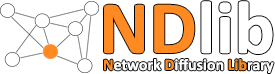

NDLib has three broad components:
- Implementations of configurable diffusion models (organized in Epidemics and Opinion Dynamics).
- A methodology to enable and configure a general simulation.
- Visualization facilities embedded in the library to explore the results.

https://ndlib.readthedocs.io/en/latest/index.html

---

<font color="#F4A460">This exercise assumes a Python 3 ipykernel environment. </font>

<font color="#F4A460"> If you are not running a virtual environment, run the cell below. Or if you are running a virtual environment, install networkx, matplotlib, etc, and jupyter/ipykernel in the virtual environment instead. </font>


In [1]:
%pip install networkx ndlib

  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.4 MB 1.9 MB/s eta 0:00:04
   ---- ----------------------------------- 0.8/6.4 MB 1.6 MB/s eta 0:00:04
   ------ --------------------------------- 1.0/6.4 MB 1.7 MB/s eta 0:00:04
   --------- ------------------------------ 1.6/6.4 MB 1.9 MB/s eta 0:00:03
   ----------- ---------------------------- 1.8/6.4 MB 1.9 MB/s eta 0:00:03
   -------------- ------------------------- 2.4/6.4 MB 1.8 MB/s eta 0:00:03
   ------------------ --------------------- 2.9/6.4 MB 2.0 MB/s eta 0:00:02
   ------------------ --------------------- 2.9/6.4 MB 2.0 MB/s eta 0:00:02
   ------------------ --------------------- 2.9/6.4 MB 2.0 MB/s eta 0:00:02
   ------------------ --------------------- 2.9/6.4 MB 2.0 MB/s eta 0:00:02
   ------------------ -----------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
<br>

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline 
plt.rcParams['figure.figsize'] = (4.0, 2.0)
import numpy as np
import operator
import random

import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
import ndlib.models.CompositeModel as gc
import ndlib.models.compartments as cs
from ndlib.utils import multi_runs


<br>
<br>

## Case Study

<br>

## 1. Revisiting the Twitch Gamers Dataset

>![Twitch][1]
>
> Twitch is an American video live streaming service that focuses on video game live streaming, including broadcasts of esports competitions, in addition to offering music broadcasts, creative content, and "in real life" streams. It is operated by Twitch Interactive, a subsidiary of Amazon.com, Inc.  - Wikipedia
>
> Users can stream video content themselves as well as watch others. It has various social features built into the platform, including but not limited to: live chats during streams, mechanisms for 'following' other users (similarly to Twitter), a subscription model for users to support others for the content they produce. Among various other features.


[1]: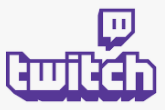


- We will re-examine the Twitch Gamers network seen previously that is built using data from the 'follow' mechanism on Twitch where nodes are Twitch users and edges are mutual follower relationships between them.

- Previously we focused on example analyst tasks that were focused on understanding the structure of the network and whether typical 'social network' properties and phenomena can be seen. Here we will another example analyst tasks with an overarching theme of finding 'important actors' (nodes) in a network. Along the way we will use various NDlib APIs to model and simulate how information could hypothetically spread across the network in ad-hoc sharing mechanism. We will also draw on additional NetworkX APIs that implement methods from Graph Theory to help focus the scope of our analysis. The methods used will demonstrative, but not be exhaustive of methods that can be used to undertake these analysis tasks.

- The dataset used in this notebook is a sample of a larger dataset collected from the public Twitch API in Spring 2018. Available at: https://github.com/benedekrozemberczki/datasets#twitch-gamers. The paper the dataset is attached to: Rozemberczki, Benedek, and Rik Sarkar. ‘Twitch Gamers: A Dataset for Evaluating Proximity Preserving and Structural Role-Based Node Embeddings’. ArXiv:2101.03091, 2021. arXiv.org, http://arxiv.org/abs/2101.03091.


<br>
<br>


### Recap: Using the network data file

In the previous "Introduction to (social) network analysis" notebook we used a file representing the Twitch Gamers dataset in the edgelist format. Here we will use an alternative network representation/file format, Graph Modelling Language (GML). It represents the same nodes and edges as the edgelist version, it just demonstrates variety in the way that networks can be represented using different data/file formats.

https://networkx.org/documentation/stable/reference/readwrite/gml.html

NetworkX uses similar naming conventions across its supported data/file formats. To read in a network as a .gml file, call the following:

```python
nx.read_gml(..)
```
https://networkx.org/documentation/stable/reference/readwrite/generated/networkx.readwrite.gml.read_gml.html

> **Extra**: NetworkX supports a variety of file formats(e.g., GML, JSON) with similar API method structure for reading from and writing to them:
>
> https://networkx.org/documentation/stable/reference/readwrite/index.html
>

In [3]:
G = nx.read_gml("twitch_sample.gml")

<br>
<br>

---

<br>
<br>


## 2. Modelling and investigating information spreading in the network 

To get started, we can break down the investigation process into 5 key steps:

1. Selecting an appropriate Diffusion model framework.
2. Configure the parameters to create a specific model.
3. Execute/run the model over some representation of time/actions.
4. Evaluate the outcomes from this.
5. (Optionally) change the model in some way, re-run and compare the outcome.


### Choosing a Diffusion model framework

NDlib supports a variety of models that are broadly categorised under two umbrella types, Epidemic models and Opinion Dynamics models. The majority of the implementations assume a static model with a fixed population, but there are a growing number of models that support dynamic populations and structures. More information on these can be found in this documentation page:

https://ndlib.readthedocs.io/en/latest/reference/reference.html#diffusion-models

In the context of this introductory notebook we will focus on choosing a model with the simplest complexity, rather than necessarily the most appropriate model for a specific research question / analyst task.

Here we will explore Epidemic models and in particular, the "**SI**" model: https://ndlib.readthedocs.io/en/latest/reference/models/epidemics/SIm.html



> The SI model was formally described in 1927 by Kermack and McKendrick in their paper "A Contribution to the Mathematical Theory of Epidemics", published in the Proceedings of the Royal Society of London, Series A.
>
>In this model, during the course of an epidemics, a node is allowed to change its status only from **Susceptible (S) to Infected (I)**.
>
>The model is instantiated on a graph having a non-empty set of infected nodes.
>
> SI assumes that if, during a generic iteration, a susceptible node comes into contact with an infected one, it becomes infected with probability **β** (beta).
>
> Once a node becomes infected, it stays infected (the only transition allowed is **S→I**).
>


Alongside, Kermack and McKendrick introduced extensions of this model including the **SIR** model (Susceptible (S) to Infected (I) to Recovered (R)) and **SIS** model (Susceptible (S) to Infected (I) to Susceptible (S)).

Perhaps unsurprisingly, extensions to these models that adjust or add to the complexity of these models have continued to be proposed. Some of these are implemented in NDlib, e.g., https://ndlib.readthedocs.io/en/latest/reference/reference.html#epidemics


<br>
<br>

### Configuring the model

Assumptions for initial simplicity:

- A single node will try to 'infect' the network or 'spread the information';
- There is a global 'infection' or 'information spreading' value (SI Model's beta) set to a value of 10%;
- At each iteration, every node will try to 'infect' or 'spread the information' to its neighbours.

In [4]:
# Model selection
model = ep.SIModel(G, seed=1) # G is our network as a NetworkX Graph object. 
#The seed parameter is optional and only used here for demonstration consistency 

# Create a configuration object for our model
model_configuration = mc.Configuration()

## What is the chance that a node tells the information to one of its connections/neighbours?
model_configuration.add_model_parameter('beta', 0.1) # Probability between 0..1 (0..100%)

## Who starts with the information?
model_configuration.add_model_initial_configuration("Infected", ["106969"]) # List of initial nodes 'infected'. This can be chosen as a random fraction of the nodes (see later in the notebook)

# Apply the created configuration to our model object
model.set_initial_status(model_configuration)

# Node ids for convenience for undertaking the Tasks later in the section:
# 106969 - random node
# 8216 - a node with the smallest degree
# 141493 - the node with the largest degree

<br>
<br>

### Executing a simulation of the model

Once we have configured our model we then need to decide how many "iterations" it should be ran for. Iterations can be somewhat regarded as "time  steps" if time is considered as a set of fixed incremental blocks, i.e., time step "1" is followed by time step "2", which is followed by time step "3", and so on.

Each iteration will perform the actions of the model as defined by the configuration. In this case every infected node in the network at a particular iteration (time step) will try to spread the information/"infect" the nodes it is connected to. 

Where the success of this is defined as a probability of "infection" information spread, i.e., beta.

> ***Warning:** running the next cell multiple times will start from the last iteration ran, not restart from the first iteration. To do this, replay the model building cell above*

In [5]:
number_of_iterations = 25 # 25 is only chosen for demonstration purposes here and should not be considered as the "best" value.

iterations = model.iteration_bunch(number_of_iterations) # run a simulation of N iterations of the model, store the results as a Python variable

<br>
<br>

NDlib will store a snapshot of the state of the network (i.e., which nodes are infected) at each iteration.

Iterations are given a unique id starting from 0, not 1, with iteration 0 representing the starting state of the model.

In [6]:
# Lets print out the data generated for the first 5 iterations of the simulation:

for iteration in iterations[:5]:
    print(iteration)
    print()

{'iteration': 0, 'status': {'65788': 0, '3181': 0, '145281': 0, '73017': 0, '48850': 0, '151230': 0, '134405': 0, '10408': 0, '66893': 0, '1679': 0, '105333': 0, '87129': 0, '129869': 0, '79768': 0, '24321': 0, '134952': 0, '36837': 0, '40675': 0, '89631': 0, '141493': 0, '113359': 0, '18259': 0, '34817': 0, '60384': 0, '91680': 0, '42097': 0, '54230': 0, '62841': 0, '155127': 0, '96169': 0, '3635': 0, '30520': 0, '16783': 0, '103123': 0, '123861': 0, '10372': 0, '98343': 0, '105041': 0, '1966': 0, '54013': 0, '49634': 0, '157118': 0, '84392': 0, '17293': 0, '75403': 0, '9068': 0, '44326': 0, '50129': 0, '34043': 0, '106969': 1, '113417': 0, '90148': 0, '133924': 0, '151401': 0, '78899': 0, '95697': 0, '95914': 0, '83757': 0, '109678': 0, '111738': 0, '125430': 0, '63150': 0, '147773': 0, '17048': 0, '116648': 0, '59892': 0, '54848': 0, '138216': 0, '87516': 0, '55012': 0, '37182': 0, '131033': 0, '157585': 0, '73900': 0, '50511': 0, '41764': 0, '53279': 0, '79010': 0, '90697': 0, '144

Interpreting the output of the cell above:

> **iteration**: A unique id representing the 'time-step' of the simulation. Increments by 1 each time starting from 0.
> 
> **status**: A Python dictionary containing the node ids of the network as keys and the values representing their 'status' as either 'susceptible' (not infected) as 0, or 'infected' as 1. The status dictionary only contains those (node) ids that have changed their status since the last iteration (time step). Any (node) id not in the status can be assumed to be in the same status as the previous iteration (time step).
> 
> **node_count**: A convenient Python dictionary that summarises the number of nodes for each status (in this case 0 or 1). 
> 
> **status_delta**: A convenient Python dictionary that summarises the number of nodes that have changed status since the last iteration (time step).

<br>
<br>

### Visualising the simulation

To visualise the "infection"/information spreading across the network we can fall back to NetworkX (underpinned by Python's matplotlib library). 

In [7]:
def draw_network(G, network_layout, node_colors, plot_title, show_labels=False, width=10, height=10):
    fig1, ax1 = plt.subplots(figsize=(width, height))
    
    # Expanded for readability
    nx.draw(G,                           # Draw the given NetworkX graph object
            ax=ax1,                      # Onto the particular matplotlib plot/axis/canvas
            pos=network_layout,          # Place the nodes at the provided fixed 2-dimensional positions (to allow consistency across plots)
            node_color=node_colors,      # Set the node colours to the provided list (i.e., specific colours for the iteration being plotted)
            with_labels=show_labels      # Whether to draw node ids on top of the nodes.
           )
    
    ax1.set_title(plot_title)                    # Set the plot title to be the provided String. In this case the iteration id.
    ax1.collections[0].set_edgecolor("black")    # Set the outer ring of the nodes to be black
    plt.show()
    
def visualise_iterations_as_network_plots(G, iterations, infected_colour="pink", susceptible_colour="white"):
    
    network_layout = nx.spring_layout(G, seed=1) # Generate fixed positions for the nodes in 2-dimensional space
    nodesInFixedOrder = G.nodes() # Safety measure for Python versions < 3.7. Generate a fixed order for the nodes as node colouring uses a list rather than a dictionary with node id as the key. 
    node_colors = {node:susceptible_colour for node in nodesInFixedOrder} # Set the colour of all nodes to be the non-infected (susceptible) color, default is white

    for iteration in iterations: # for each iteration of the simulation
        iterationID = str(iteration["iteration"]) # get the unique iterations id, i.e., 0, 1, 2, 3, 4, 5..N, as a Python string

        for node, status in iteration["status"].items(): # loop over the "status" of each node after the iteration has ran
            node_colors[node] = infected_colour if status == 1 else susceptible_colour # infected nodes are made the chosen infected_colour (default is pink)

        node_colors_to_use = [node_colors[node] for node in nodesInFixedOrder] # convert the node colours into a list as NetworkX's draw method does not accept a dictionary

        draw_network(G, network_layout, node_colors_to_use, iterationID) # call the draw_network method defined above to plot the network for the iteration.

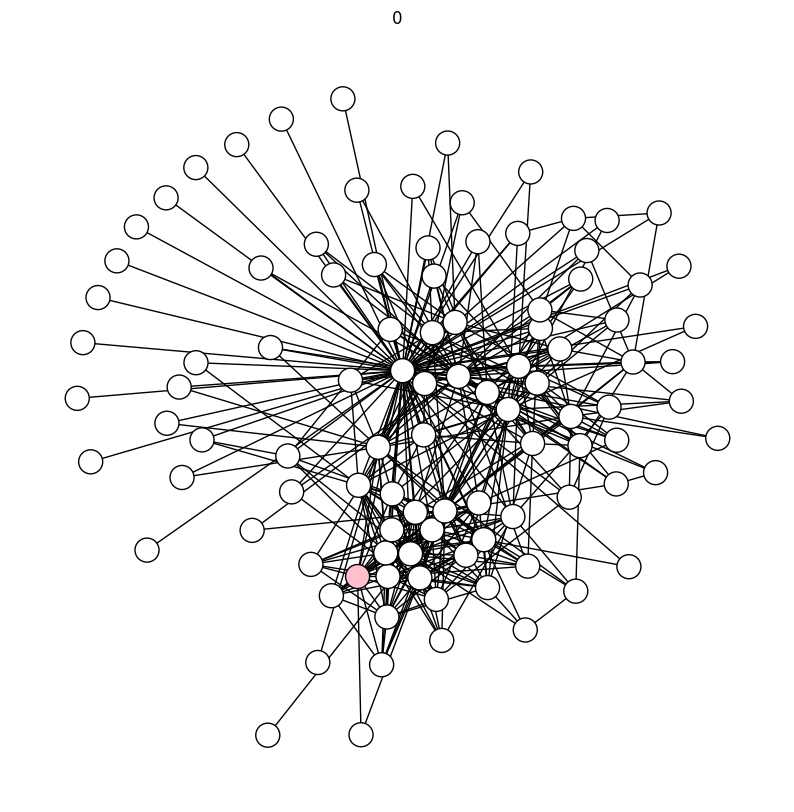

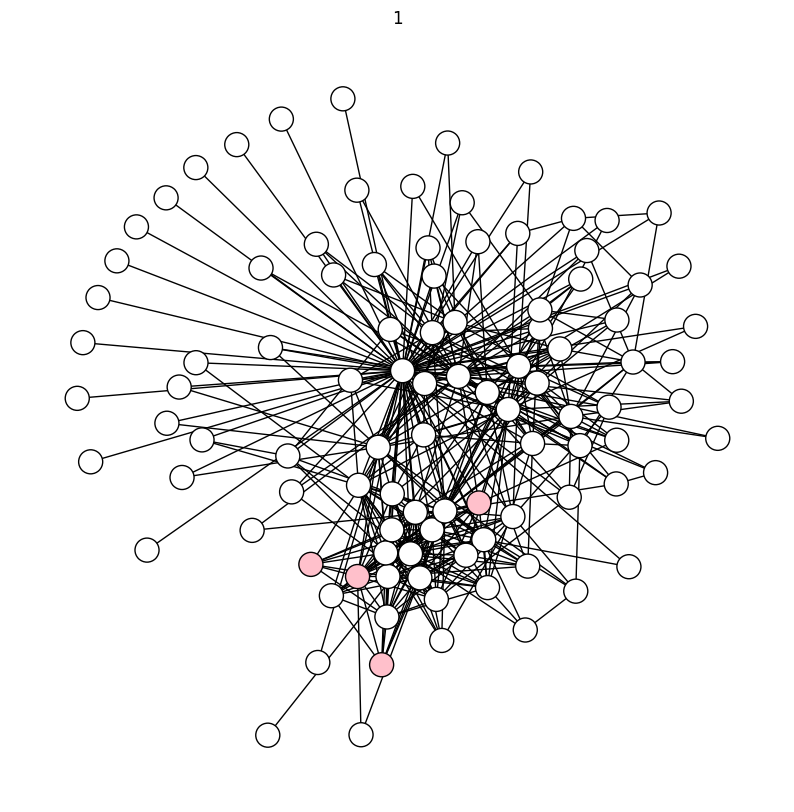

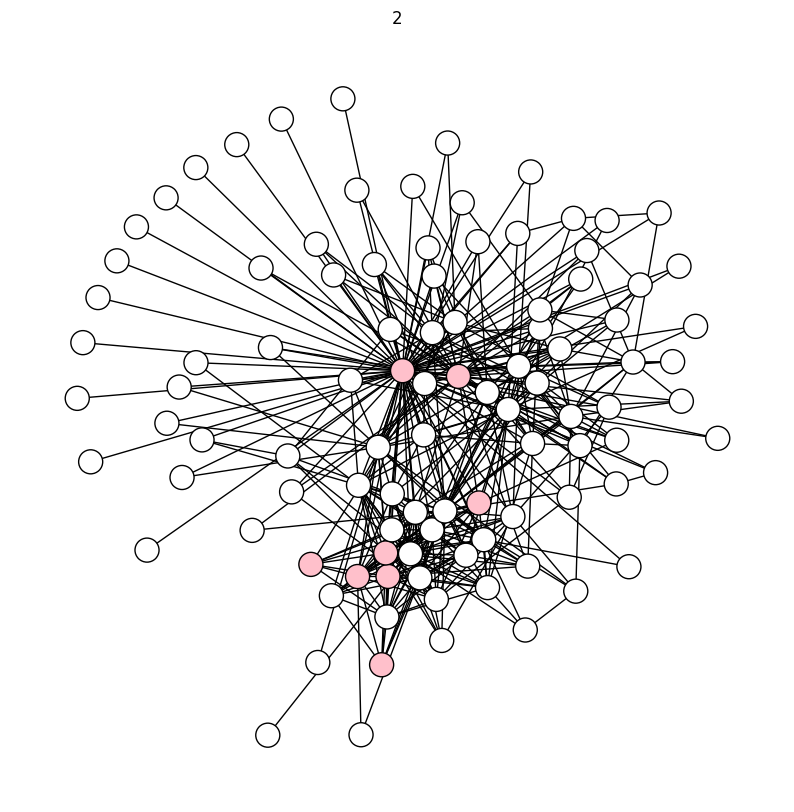

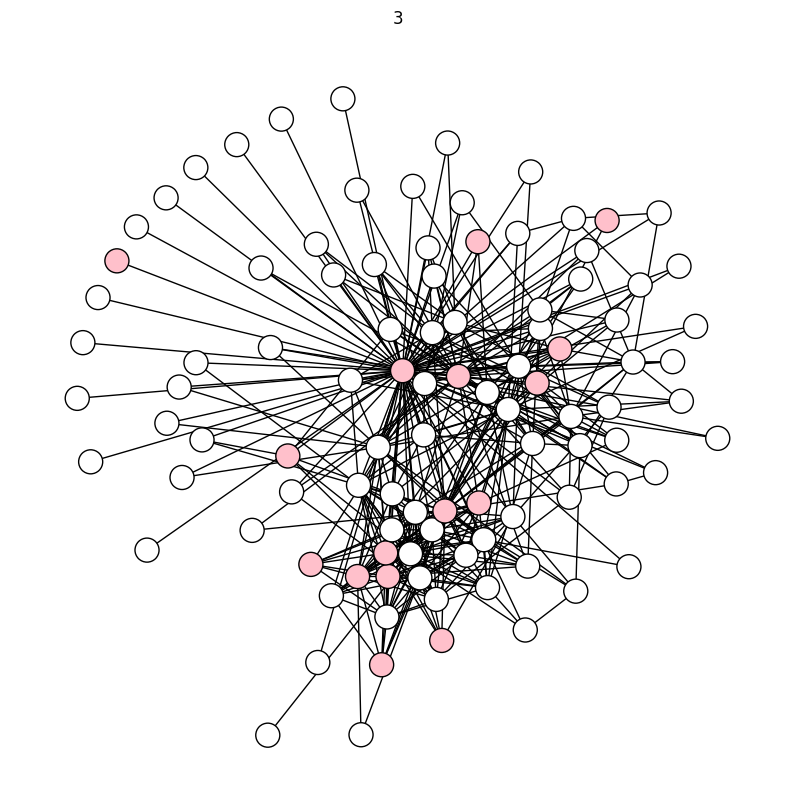

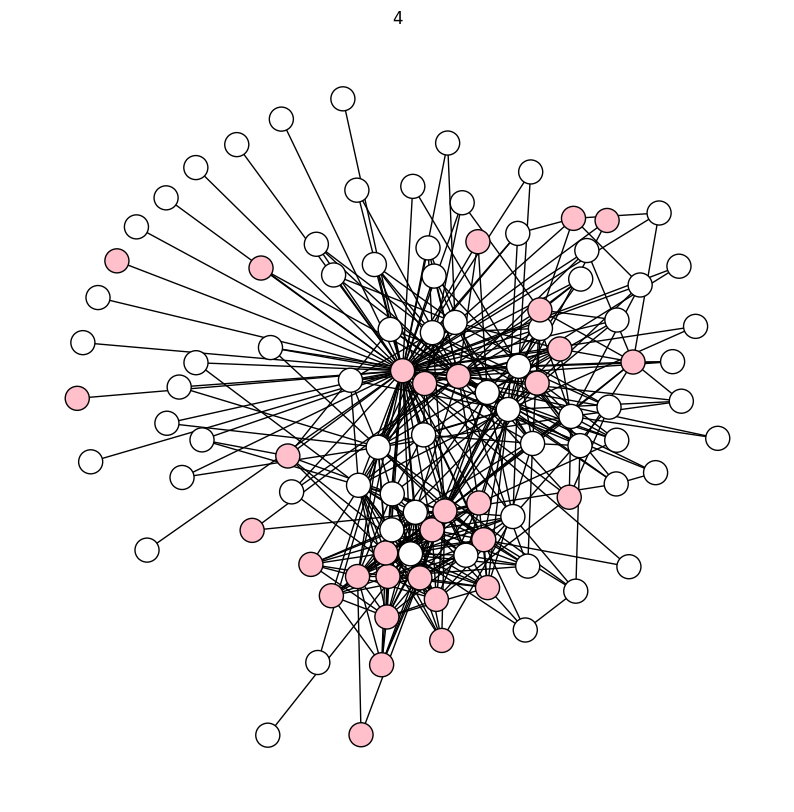

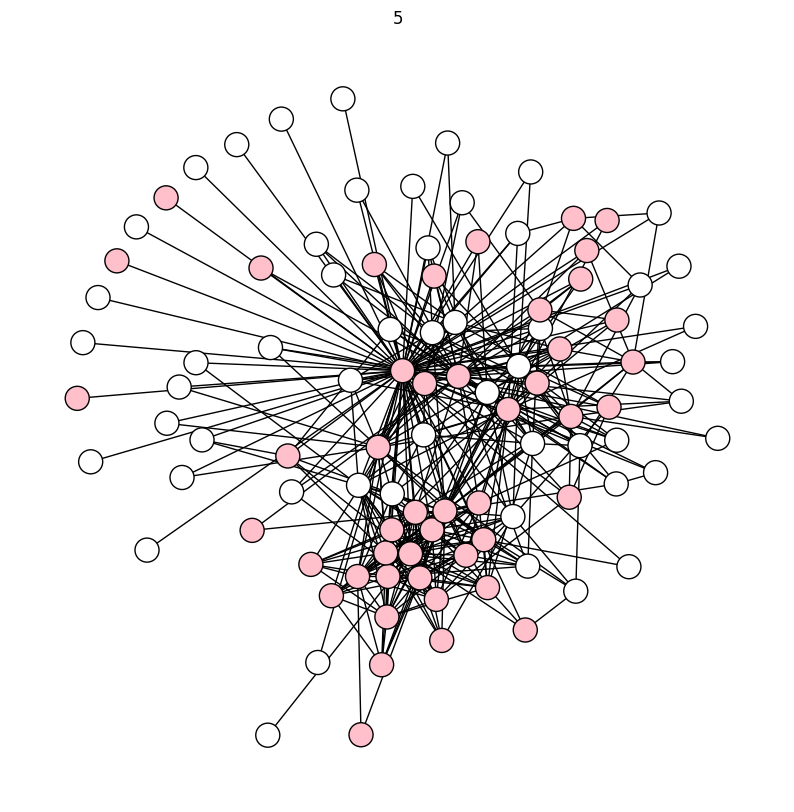

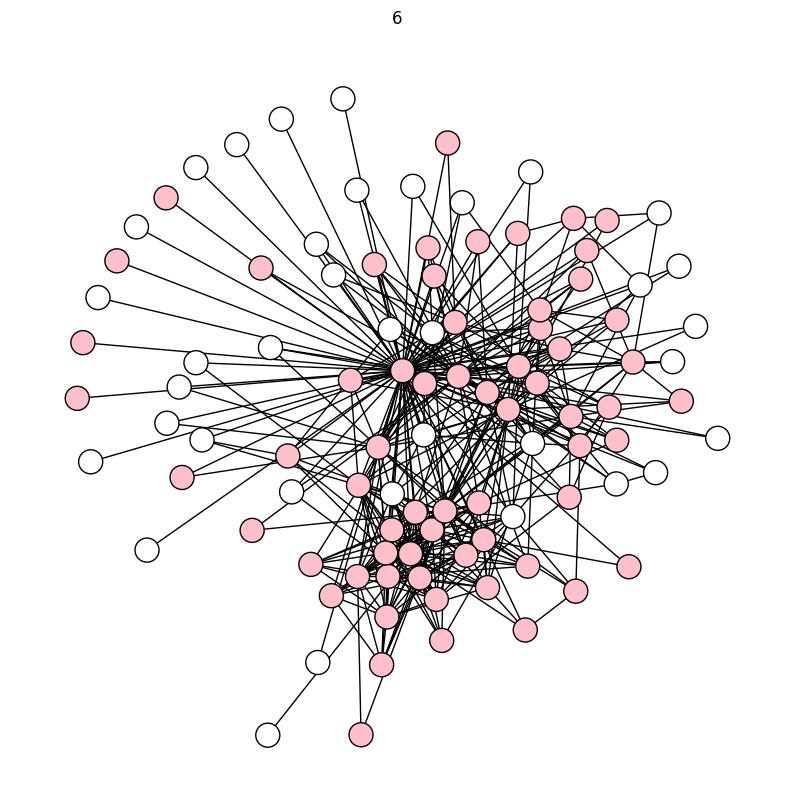

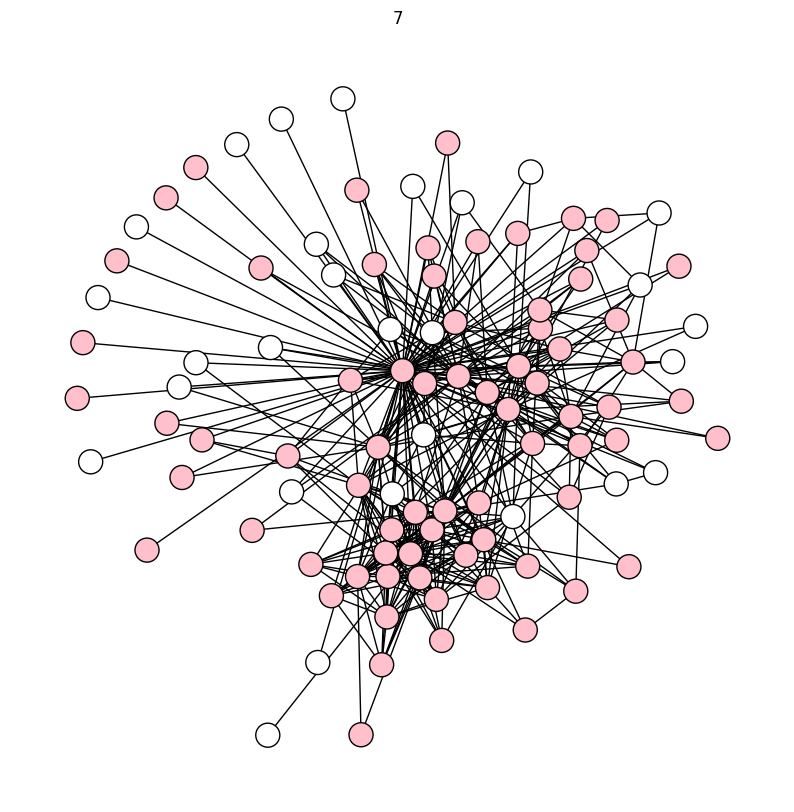

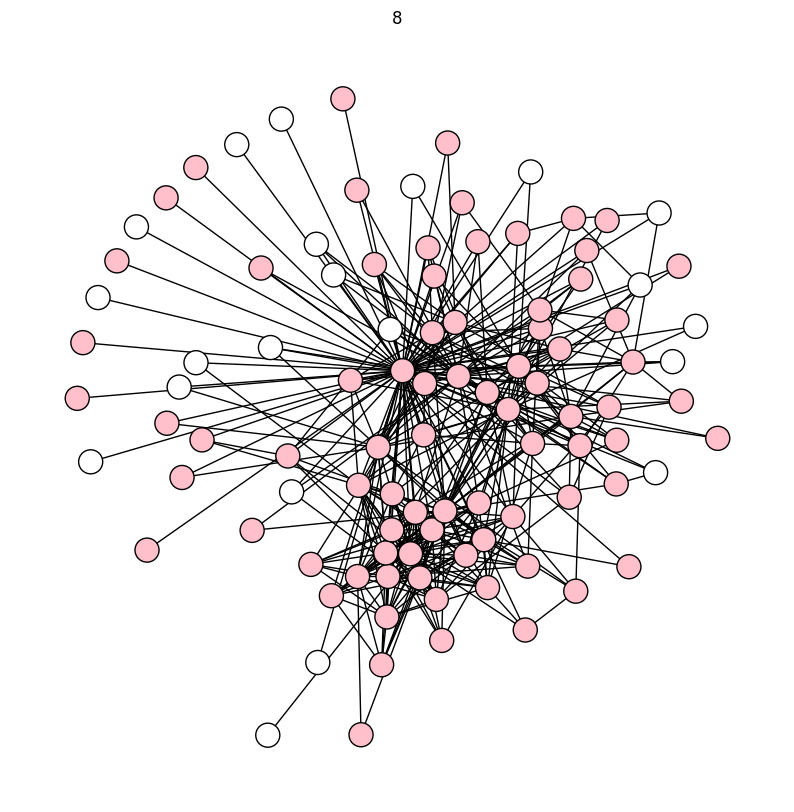

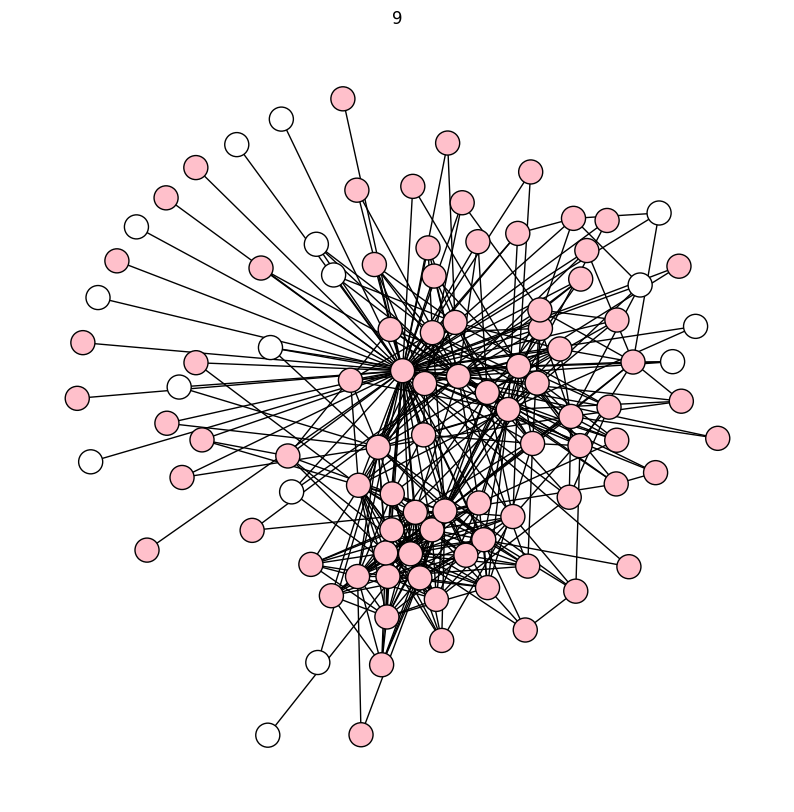

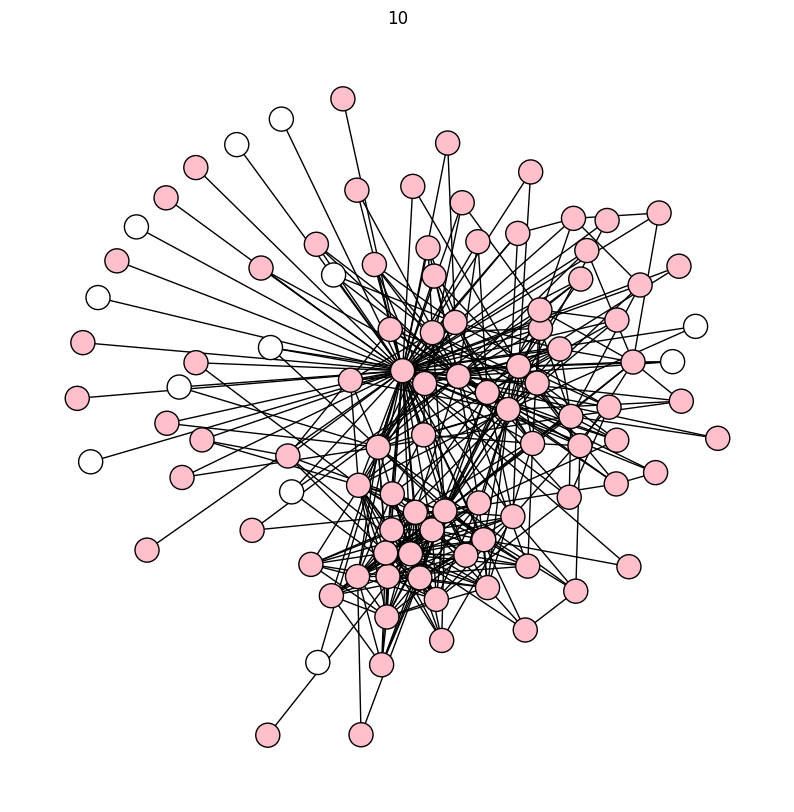

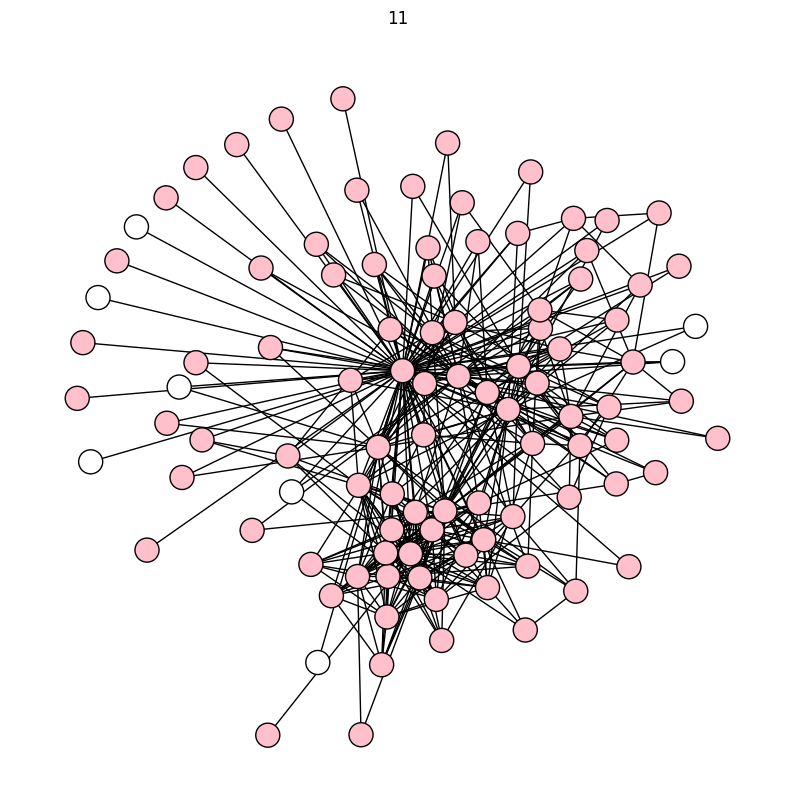

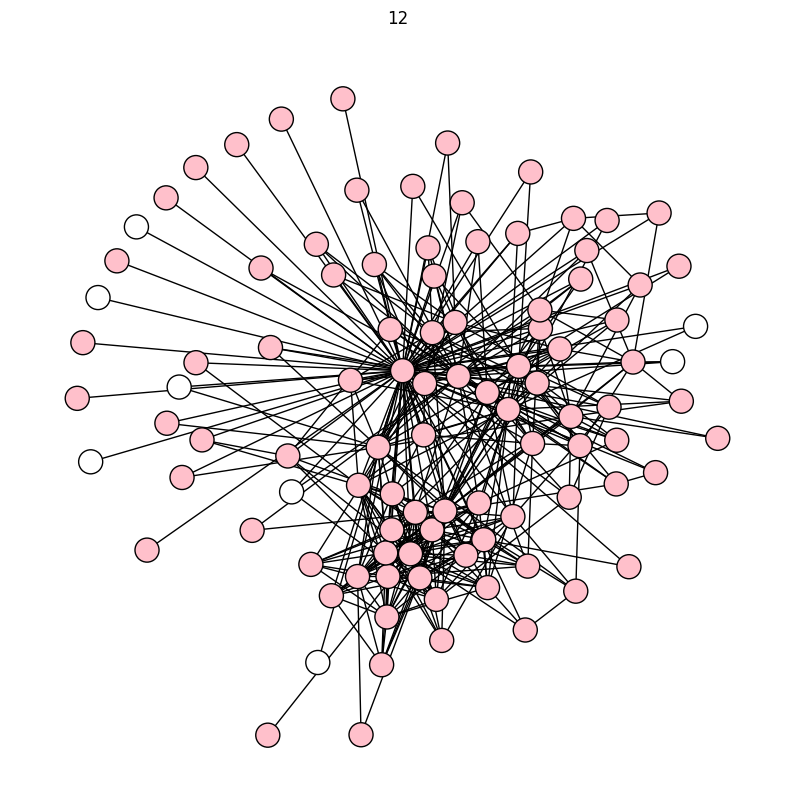

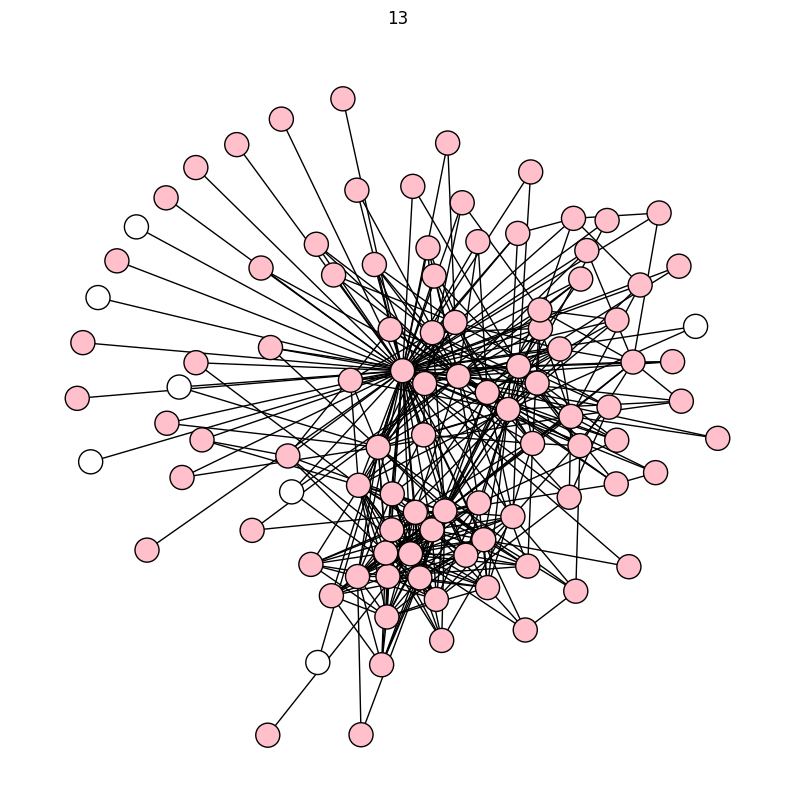

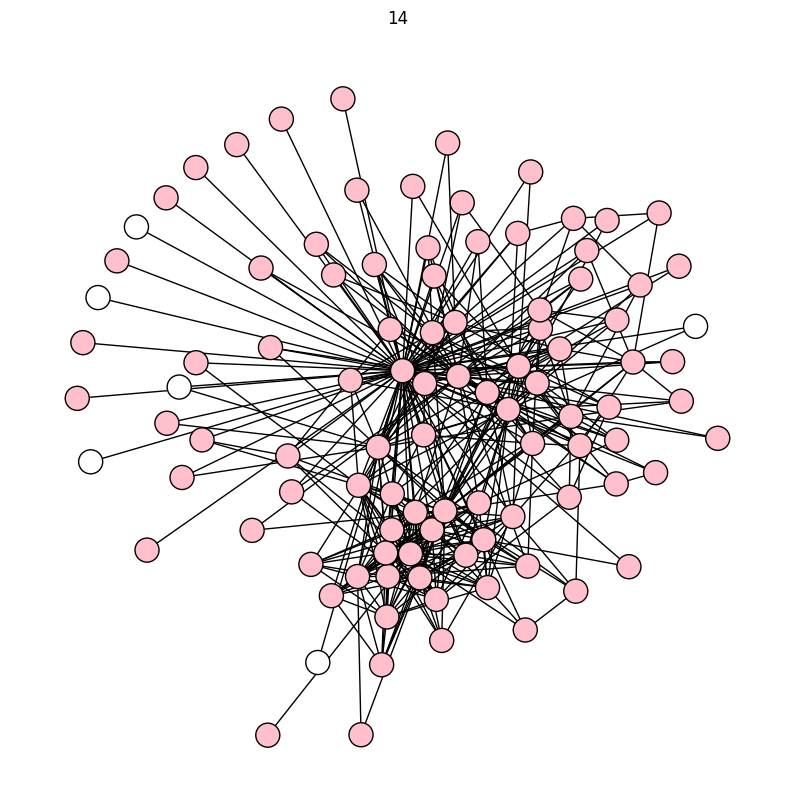

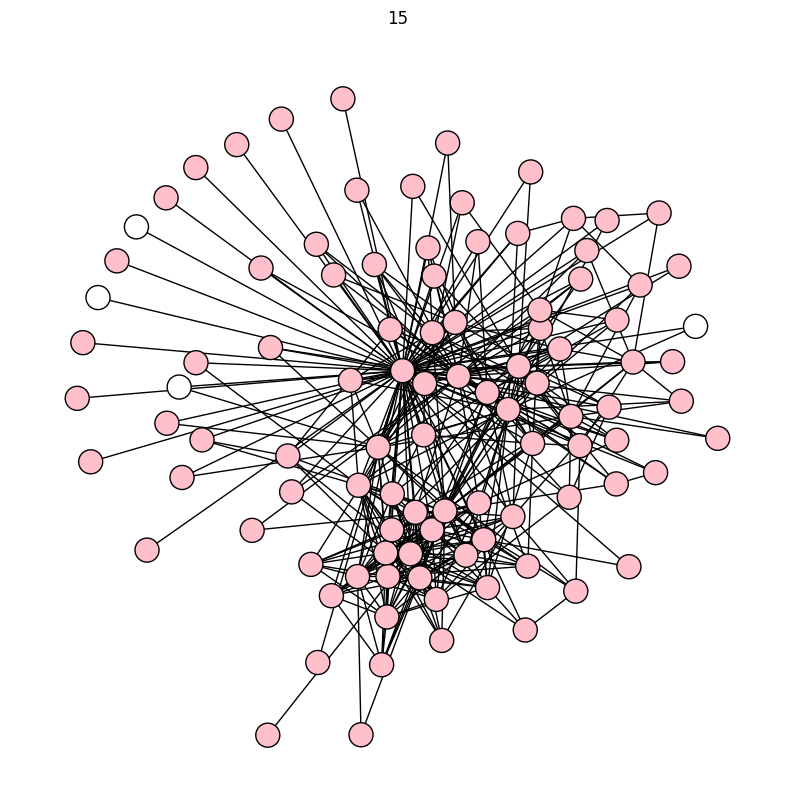

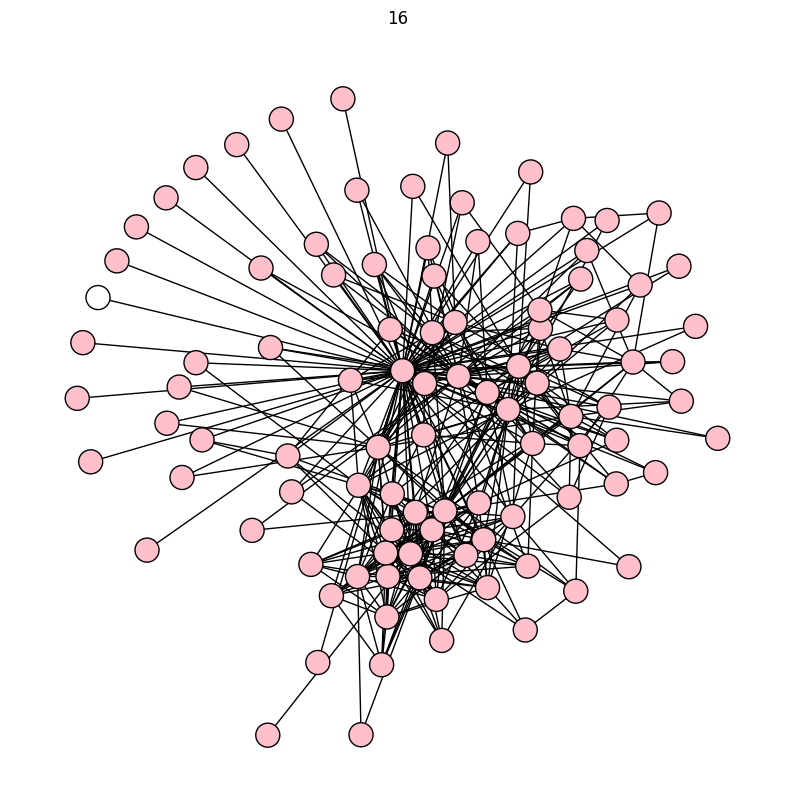

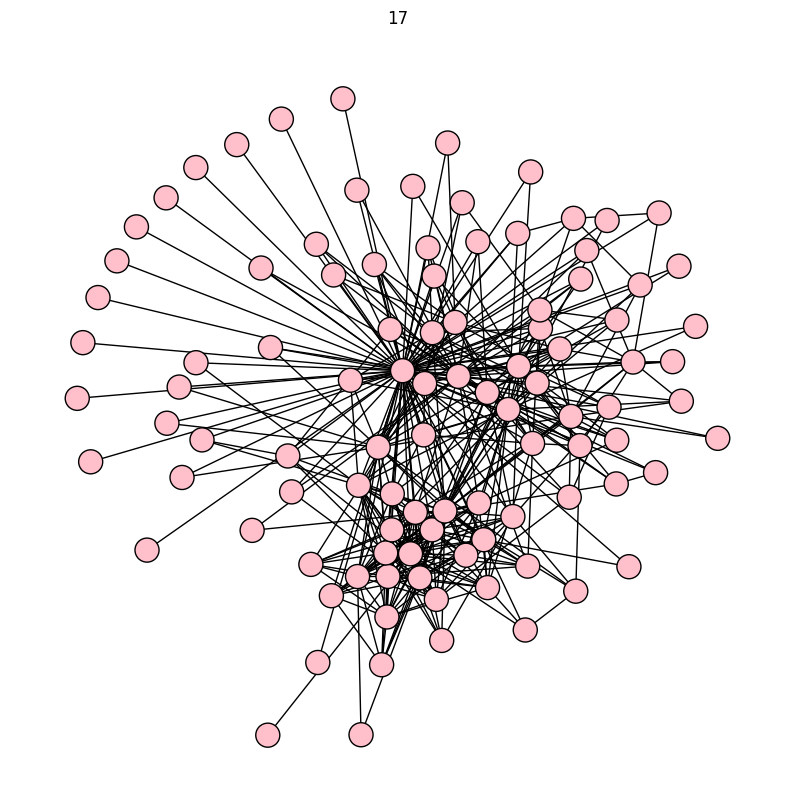

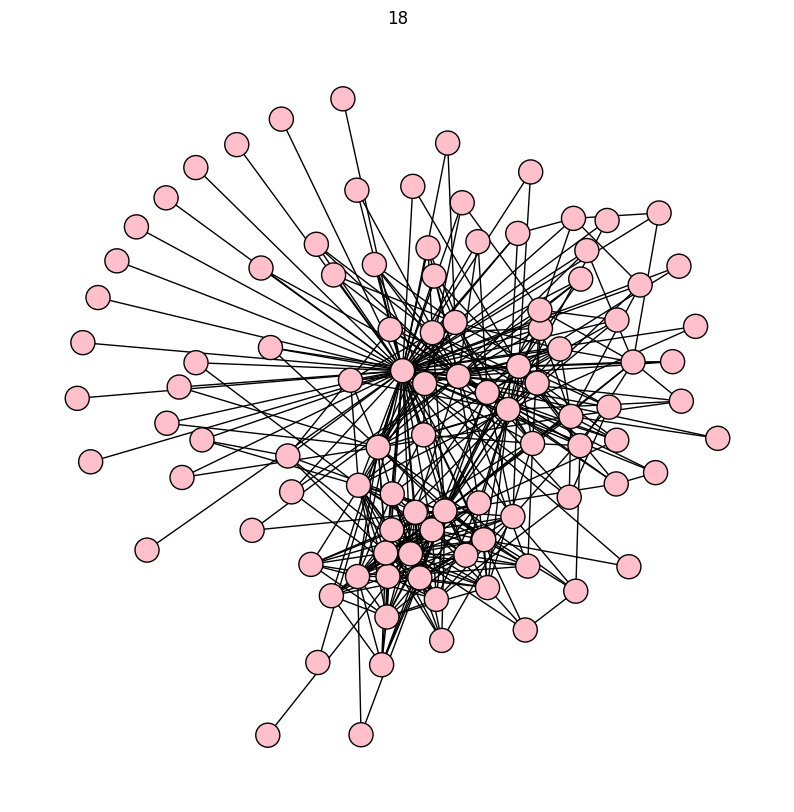

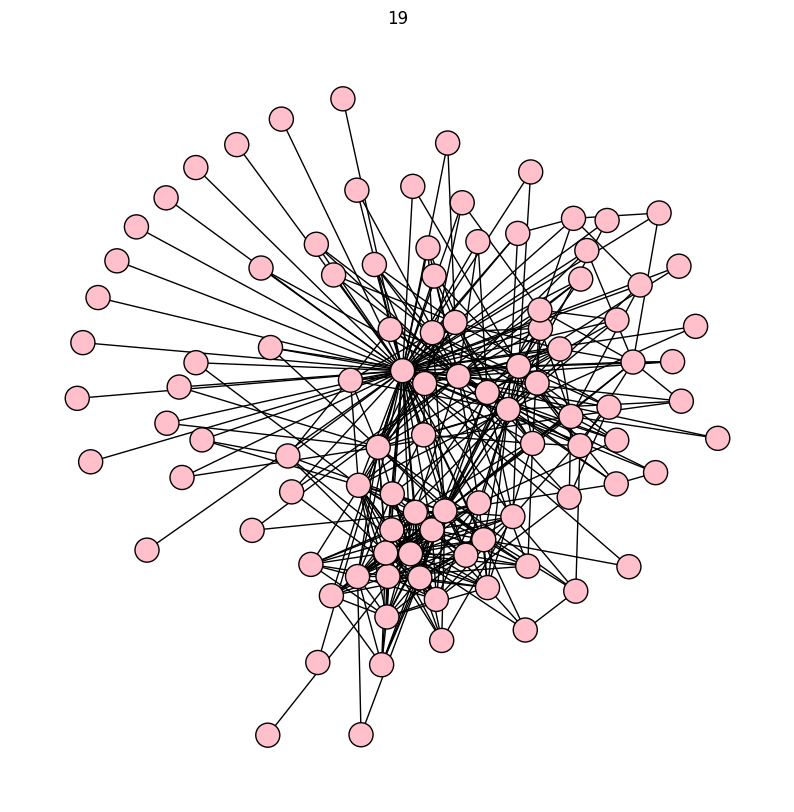

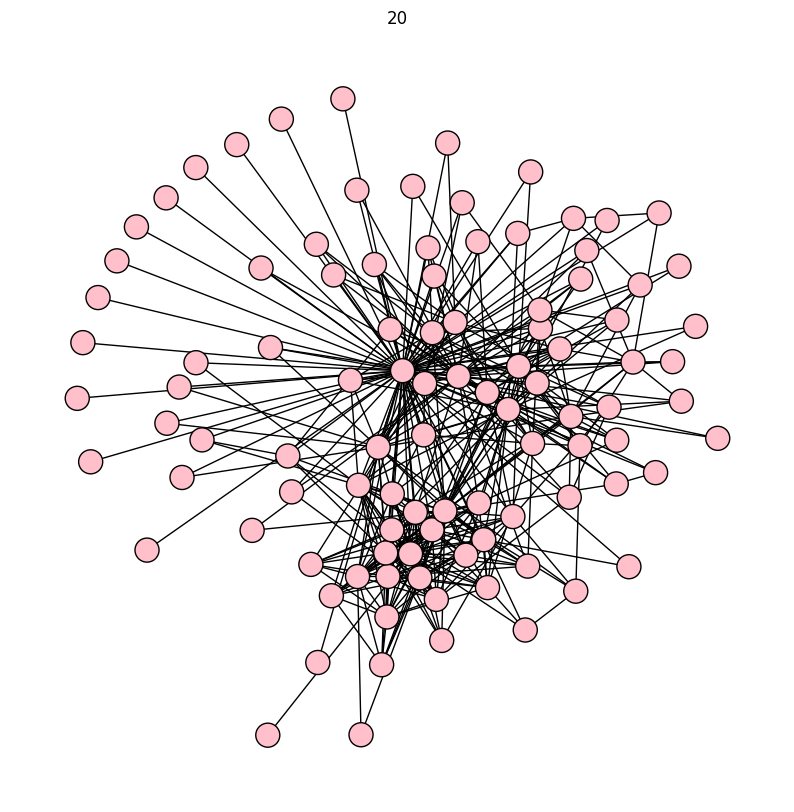

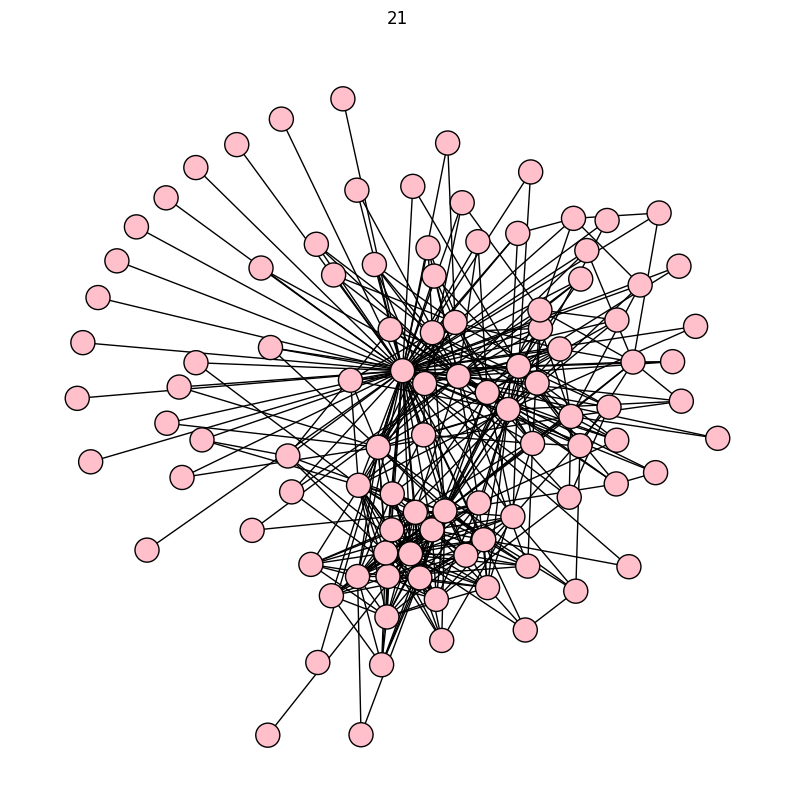

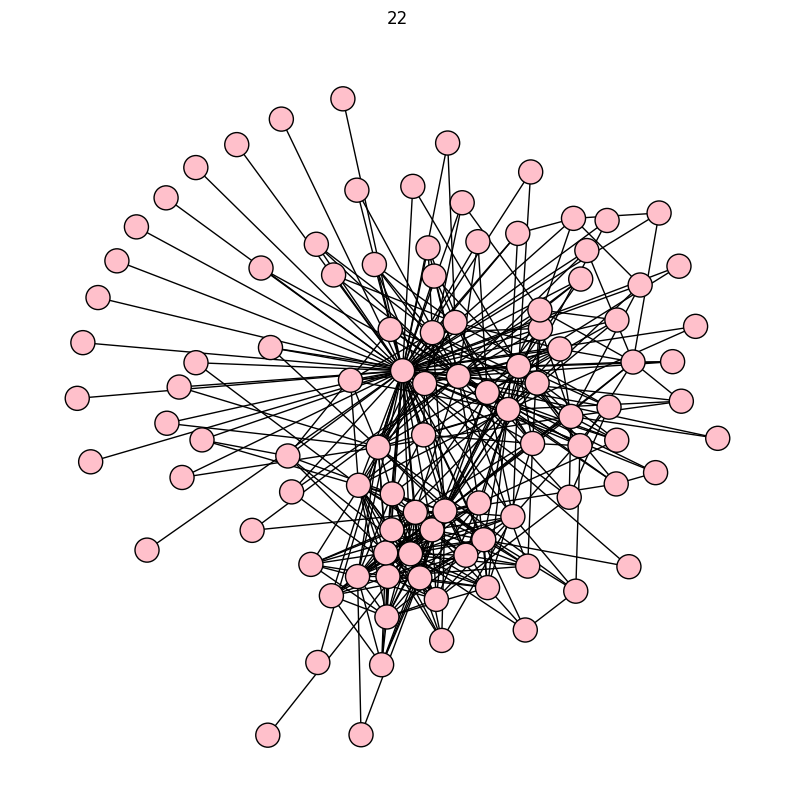

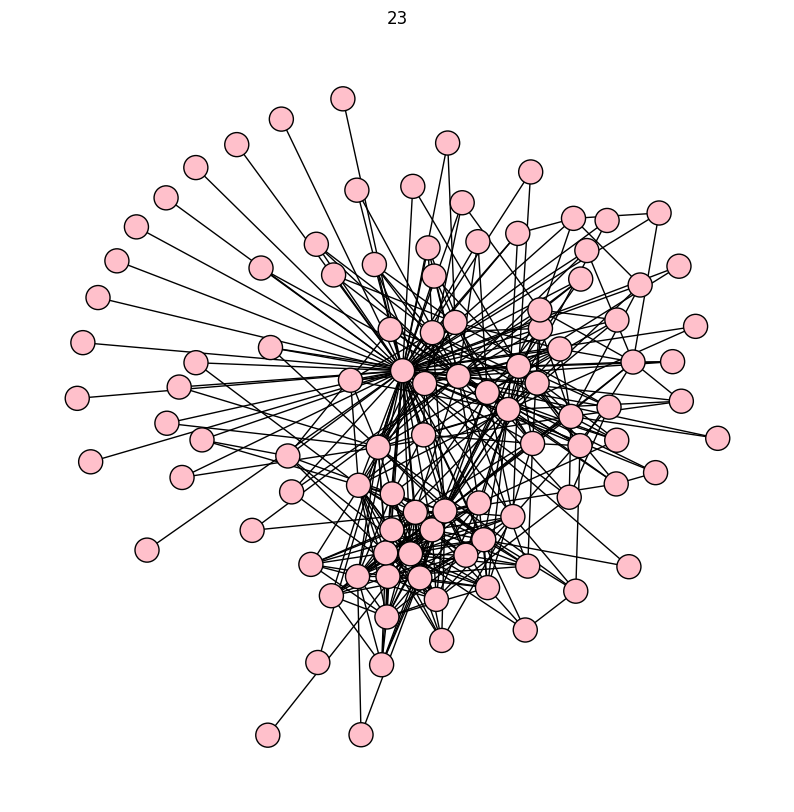

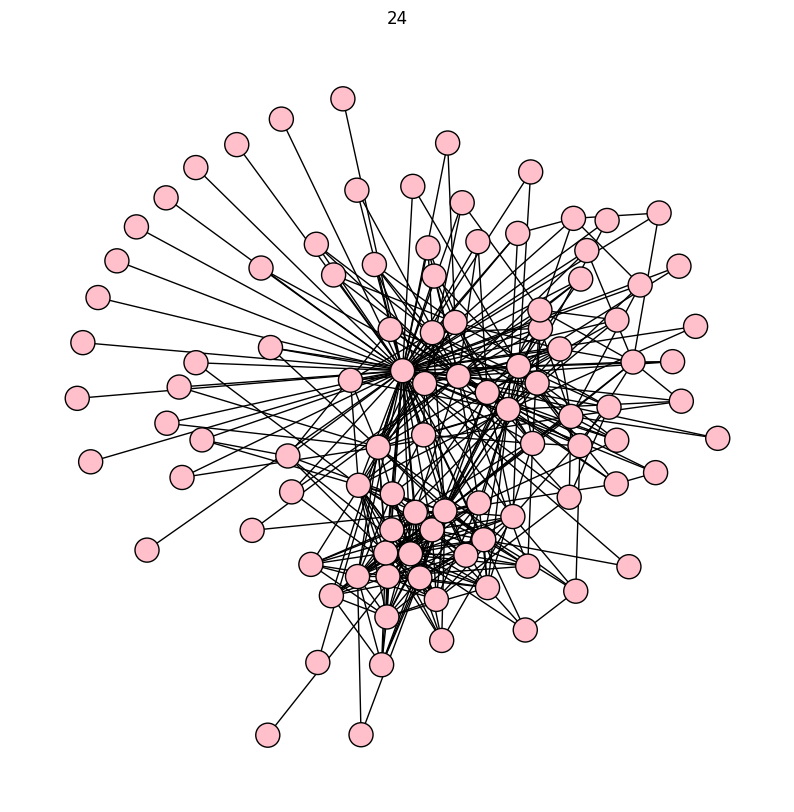

In [8]:
visualise_iterations_as_network_plots(G, iterations) # Call the method defined in the (hidden) cell above to plot each iteration of the simulation in order

### Tasks

The configuration set above shows a single simulation of a specific set of model parameters (the initial node infected and the global infection probability, beta). Go back to the cell under "Configuring the model" and modify to observe how the simulation unfolds differently with different values for these parameters.
>
> 1. Experiment in changing the model configuration to observe how changing the initial 'infected' node effects how the 'infection'/information spreads:
>   - Change the initial 'infected' node from the random node to the node with the largest degree "141493"
>   - Change the initial 'infected' node to a node with the smallest degree e.g., "8216"
> 2. Experiment in changing the model configuration to observe how changing the probability of spreading effects effects how the 'infection'/information spreads:
>   - Change the value of  beta, from 0.1 to 0.01, 0.25, 0.5, and 1.0
>   - Combine this with different initial 'infected' nodes
> 3. Change the random seed from 1 to several other integer values and observe the differences it makes where beta < 1.0

<br>
<br>

#### Summary of observations

Of the tasks:

- As beta increases, the 'quicker' the network is flooded.
- However the initial 'infected' node (source of the information) makes a difference due to its position in the network structure, e.g., its degree and eccentricity (for recap: see the "Introduction to (social) network analysis" with the Twitch Gamers dataset).

<br>
<br>

---

<br>
<br>

## 3. Model Evaluation

As we've seen with Network decomposition tasks, visualisations of Networks can have utility but this arguably reduces as the number of nodes and edges increases. Therefore to help evaluate and draw conclusions from the models we may need to lean on alternative representations of the data produced from the iterations.

NDlib has a few built-in APIs for conveniently plotting the data to show changes in nodes statuses over the iterations.

### Trends

no display found. Using non-interactive Agg backend


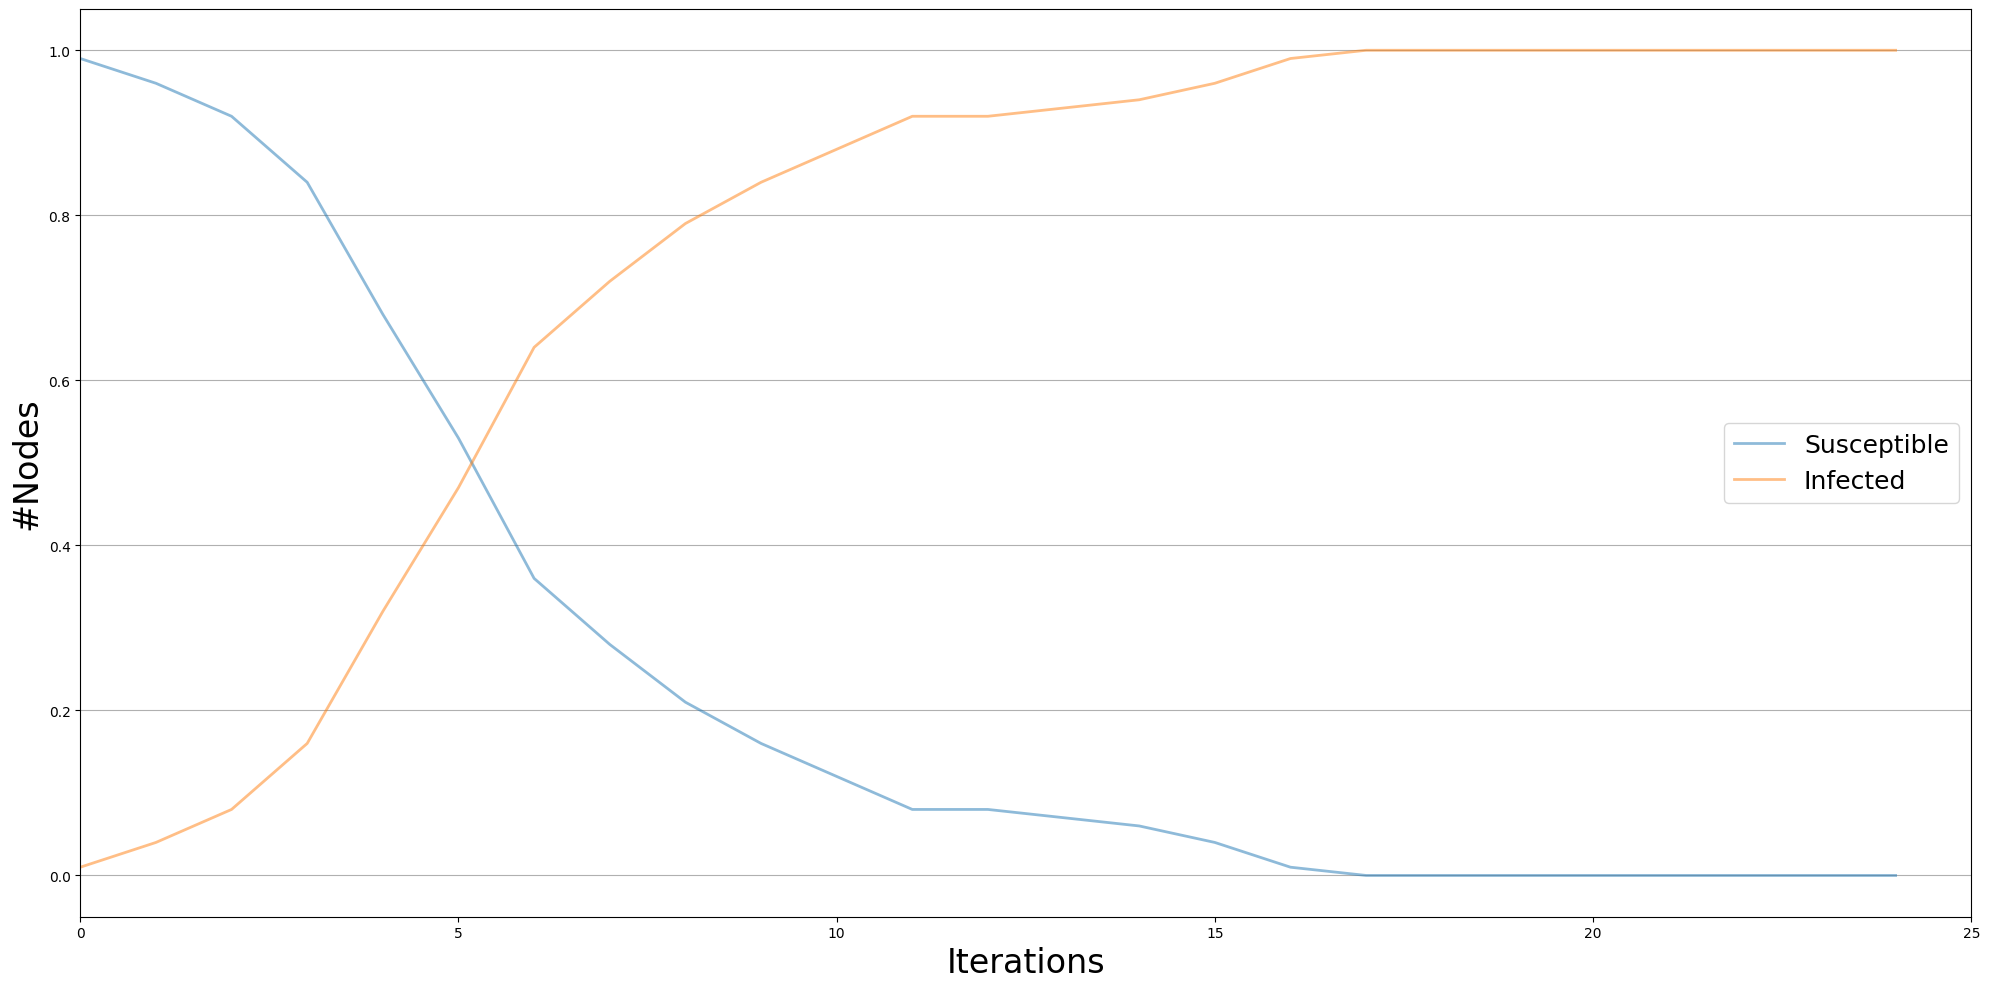

In [9]:
trends = model.build_trends(iterations)

from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend
%matplotlib inline 
viz = DiffusionTrend(model, trends)
viz.plot()

> Note: the y-axis should be Fraction of Nodes, not #Nodes (Number of nodes).

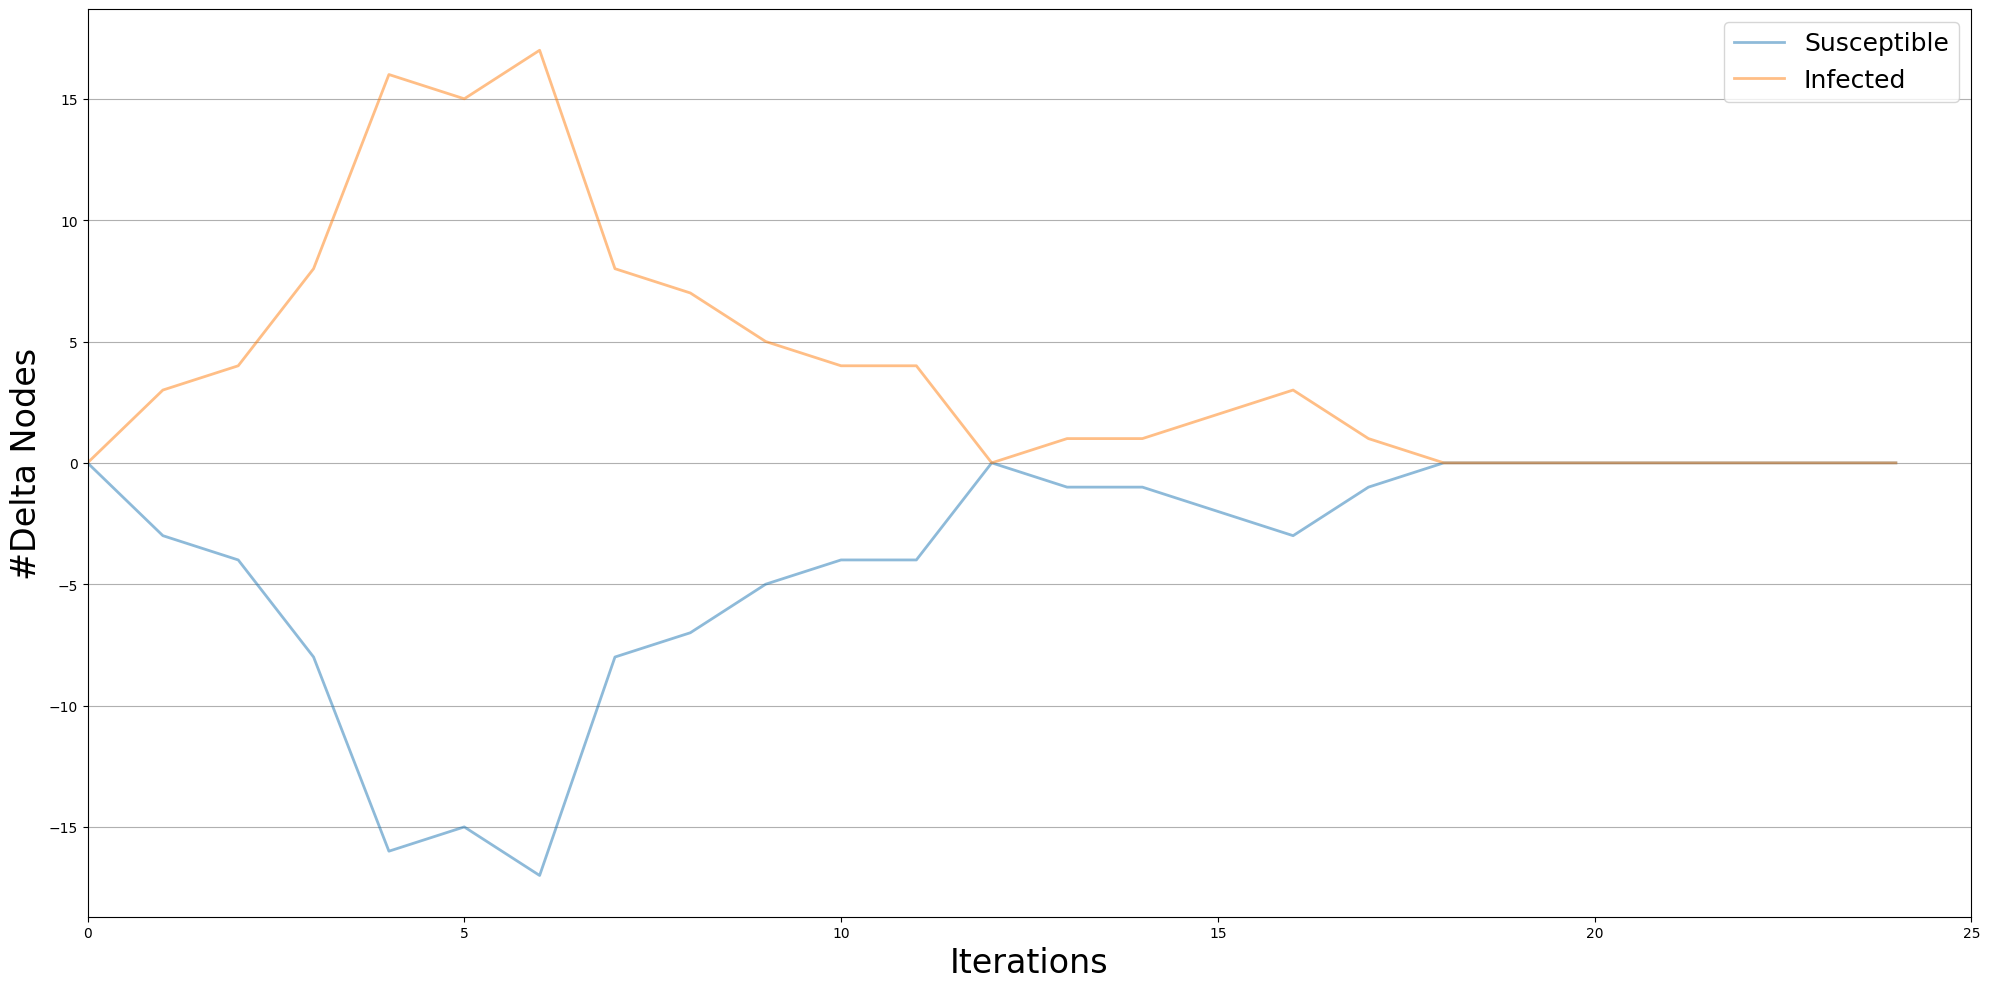

In [10]:
from ndlib.viz.mpl.DiffusionPrevalence import DiffusionPrevalence
viz = DiffusionPrevalence(model, trends)
viz.plot()

You can also use the raw summary data produced by either the model's build_trends(..) function or the original iterations data passed into it to plot it or analyse it in a specific way for the task/question you want to answer.

In [11]:
print(trends)

[{'trends': {'node_count': {0: [99, 96, 92, 84, 68, 53, 36, 28, 21, 16, 12, 8, 8, 7, 6, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0], 1: [1, 4, 8, 16, 32, 47, 64, 72, 79, 84, 88, 92, 92, 93, 94, 96, 99, 100, 100, 100, 100, 100, 100, 100, 100]}, 'status_delta': {0: [0, -3, -4, -8, -16, -15, -17, -8, -7, -5, -4, -4, 0, -1, -1, -2, -3, -1, 0, 0, 0, 0, 0, 0, 0], 1: [0, 3, 4, 8, 16, 15, 17, 8, 7, 5, 4, 4, 0, 1, 1, 2, 3, 1, 0, 0, 0, 0, 0, 0, 0]}}}]


Interpreting the output of the cell above:

> **trends**: Contains the summary data dictionary objects
> 
> **node_count**: A dictionary object with keys for each status (0 and 1). Each key (status) has a list as its value. Each item in the list represents the number of nodes with that particular status. The lists are ordered in ascending order with the iterations, i.e., the item at index 0 represents the number of nodes with that status at iteration 0, index 1 at iteration 1, etc.
> 
> **status_delta**: Similarly structures to the above, however the values of the lists represent the number of nodes that have changed status after the iteration. In the case of the SI model, the status_delta for the Susceptible status (0) will always be either 0 (no nodes were infected in the iteration) or a negative integer. Likewise the status_delta for the Infected status (1) will always be either 0 (no nodes were infected in this iteration) or a positive integer. As a constraint of the SI model is that nodes are Susceptible until Infected and cannot go back, these values will be proportionate to one another. In more complex models (e.g. SIR) this will not necessarily be true.

#### Custom measures

Depending on the research question you want to answer, you may wish to define your own measures that summarises specific properties of the data. For example, you want to know:

- How long does it take to flood the network?
- How much of the network is 'infected' after some time?

To enable this, we *could* implement something similar to the method below:

In [12]:
def calculate_iterations_to_reach_threshold(trends, number_of_nodes, threshold, verbose=False):
    
    # Calculate the number of nodes needing to be "infected" given the threshold
    threshold_as_number_of_nodes = (number_of_nodes*threshold)
    
    # Create a list to store the results, with each item in the list being a 2-item tuple where the 
    # first item is a boolean value for whether threshold was met or no and the second being the 
    # iteration it occurred in
    iteration_counts_per_simulation = []
    
    # For each simulation (this could be a single execution/run of the model)
    for simulation in trends:
        
        # Get the list of "infected" nodes per iteration from the trends data
        number_infected_per_iteration = simulation["trends"]["node_count"][1]
        
        # Loop over each iteration and if the number of "infected" nodes is greater
        # than the threshold then stop there and record the iteration number
        threshold_met = False
        iteration_count = 0
        for iteration, number_infected in enumerate(number_infected_per_iteration):
            # If the value of the verbose parameter is True, print this information for this iteration
            if verbose:
                print(f"Iteration: {iteration}    Number infected: {number_infected}    ({(number_infected / number_of_nodes)})")
            
            if number_infected < threshold_as_number_of_nodes:
                iteration_count += 1
            else:
                threshold_met = True
                break
                
            
            
        # Add whether the threshold was met and at what iteration to the results list
        iteration_counts_per_simulation.append((threshold_met, iteration_count))
        
    return iteration_counts_per_simulation

#####

required_threshold_of_fraction_of_infected_nodes = 1.0

results = calculate_iterations_to_reach_threshold(
    trends, 
    G.number_of_nodes(), 
    required_threshold_of_fraction_of_infected_nodes,
    True
)

print()
print(f"Threshold met = {results[0][0]} after {results[0][1]} iterations from the initial iteration")

Iteration: 0    Number infected: 1    (0.01)
Iteration: 1    Number infected: 4    (0.04)
Iteration: 2    Number infected: 8    (0.08)
Iteration: 3    Number infected: 16    (0.16)
Iteration: 4    Number infected: 32    (0.32)
Iteration: 5    Number infected: 47    (0.47)
Iteration: 6    Number infected: 64    (0.64)
Iteration: 7    Number infected: 72    (0.72)
Iteration: 8    Number infected: 79    (0.79)
Iteration: 9    Number infected: 84    (0.84)
Iteration: 10    Number infected: 88    (0.88)
Iteration: 11    Number infected: 92    (0.92)
Iteration: 12    Number infected: 92    (0.92)
Iteration: 13    Number infected: 93    (0.93)
Iteration: 14    Number infected: 94    (0.94)
Iteration: 15    Number infected: 96    (0.96)
Iteration: 16    Number infected: 99    (0.99)
Iteration: 17    Number infected: 100    (1.0)

Threshold met = True after 17 iterations from the initial iteration


<br>
<br>

---

<br>
<br>

## 4. Simulation Testbed

Optionally, we can combine the methods introduced in Sections 2 and 3 of this notebook into two complementary convenience methods:

In [14]:
# Convenience methods for model building, running, and evaluation.

def runSIModelOnANetwork(G, b, i, initial_infected=None, fraction_infected=None, model_seed=1):

    # Create the SI model for the provided network
    model = ep.SIModel(G, seed=model_seed)
    model_configuration = mc.Configuration()

    # Configure the model
    #    What is the chance that a node tells the information to one of its connections/neighbours?
    model_configuration.add_model_parameter('beta', b)
    
    #    Who starts with the information?
    if initial_infected is not None: # assumes initial_infected will be a valid Python list of node ids
        model_configuration.add_model_initial_configuration("Infected", initial_infected)
    else:
        model_configuration.add_model_parameter("fraction_infected", fraction_infected) # Alternative not yet seen, see: https://ndlib.readthedocs.io/en/latest/reference/models/epidemics/SIm.html

    # Set the configuration and run the simulation
    model.set_initial_status(model_configuration)
    iterations = model.iteration_bunch(i)
    
    return model, iterations


In [13]:
def evaluateModel(network, model, trends, threshold):
    
    # Create the summary, trends data from the iteration data
    trends = model.build_trends(iterations)

    # Create a NDlib DiffusionTrend plot
    diffusion_trend = DiffusionTrend(model, trends)

    # Calculate whether the threshold of infected nodes was reached and at what iteration. 
    results = calculate_iterations_to_reach_threshold( # Uses the calculate_iterations_to_reach_threshold method defined in Section 3. Custom measures
        trends,
        network.number_of_nodes(),
        threshold,
        False
    )
    
    return diffusion_trend, results

<br>

And use these to experiment with different configurations of the model and its evaluation. E.g.:

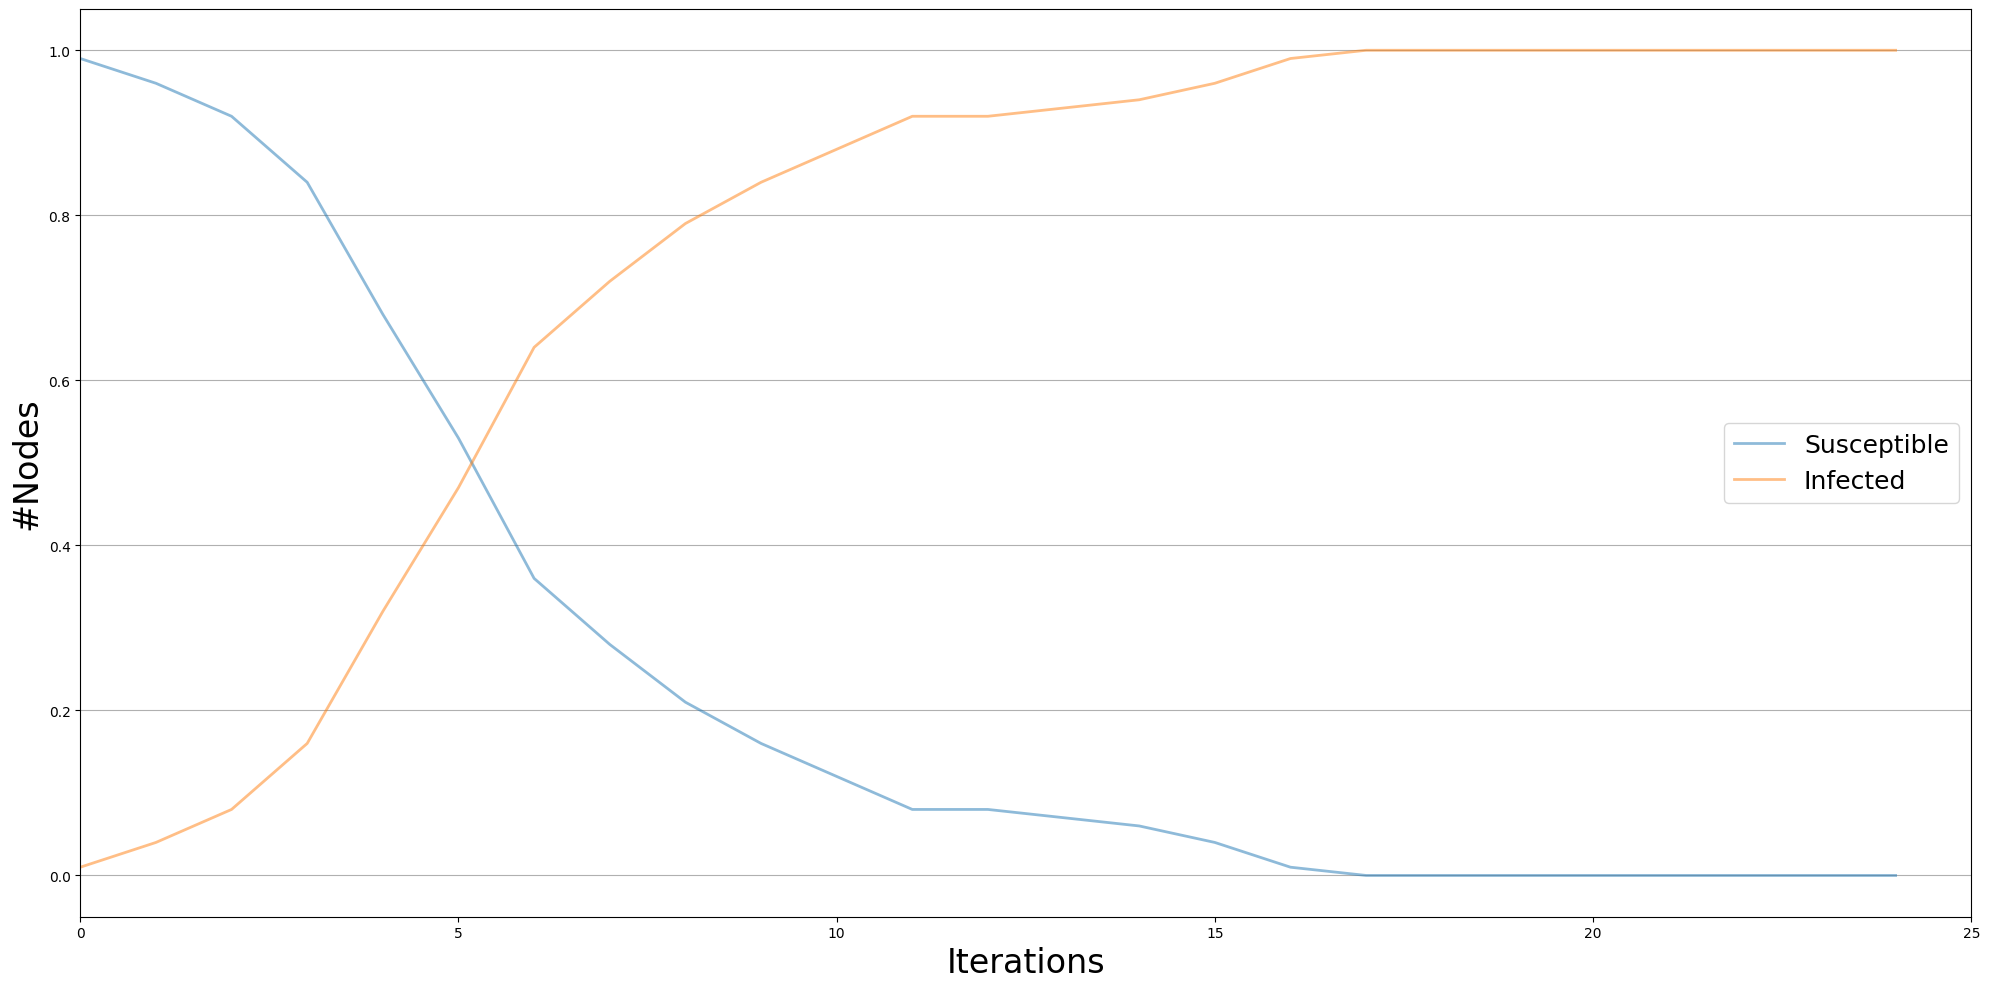


Threshold met = True after 6 iterations from the initial iteration


In [15]:
# Model configuration parameters
network = G

beta = 0.1
number_of_iterations = 25

initial_infected_nodes = ["106969"]
#fraction_of_nodes_infected = 0.01    # 1%

evaluation_threshold = 0.5  # Half the number of nodes infected

# Build and run the model
model, iterations = runSIModelOnANetwork(
    network,
    beta,
    number_of_iterations,
    initial_infected = initial_infected_nodes
    #fraction_infected = fraction_of_nodes_infected
)

# Evaluate the outcome
viz, threshold_analysis = evaluateModel(
    network,
    model, 
    iterations, 
    evaluation_threshold,
)

#visualise_iterations_as_network_plots(G, iterations) # Optionally plot the network visualisations for each iteration

viz.plot()

print()
print(f"Threshold met = {threshold_analysis[0][0]} after {threshold_analysis[0][1]} iterations from the initial iteration")

<br>

> **Extra**: Using the Simulation Testbed defined above, experiment with similar tasks to those defined in Section 2. However, rather than picking the specific node(s) as the initial "infected"/source(s) of the information, let NDlib select a random fraction of nodes instead. 
>
> Comment out the following two lines:
>> ```python 
initial_infected_nodes = ["106969"]
...
initial_infected = initial_infected_nodes
>> ```
>
> and un-comment the following two lines:
>> ```python 
fraction_of_nodes_infected = 0.01      # 1%
...
fraction_infected = fraction_of_nodes_infected
>> ```
>
> Experiment with different values for for fraction of infected nodes along with beta and observe the differences it makes to the spread of the "infection"/information.

<br>
<br>

---

<br>
<br>


## 5. Who is "best" to select as the initial "infected"/source of information?

From a hypothetical analyst perspective, the methods explored so far are useful for predicting the effects of information spreading from specific nodes of interest under different conditions, as well as under random conditions.

However, it may be the case that you do not know what specific nodes are of interest to examine. You could exhaustively configure, run, and evaluate the model against some criteria of "interestingness" (e.g., node that results in the network being flooded with the information the quickest). Alternatively you could lean on network analysis techniques to help select potential nodes of interest.

In previous notebooks we have broadly examined networks as a whole in order to expose (and in some cases compare) social phenomena reflected in their structure, except for a few cases such as individual node degree and neighbours.

### Centrality measures

Here we will examine additional network measures that try to examine and quantify the centrality of the roles that nodes play relative to other nodes in a network. We will use NetworkX APIs to help with this (https://networkx.org/documentation/stable/reference/algorithms/centrality.html). While we are using these as part of diffusion modelling they are not exclusively useful for this task and could also be used for network analysis. You may wish to implement these as part of the analysis of the other notebooks seen so far. 

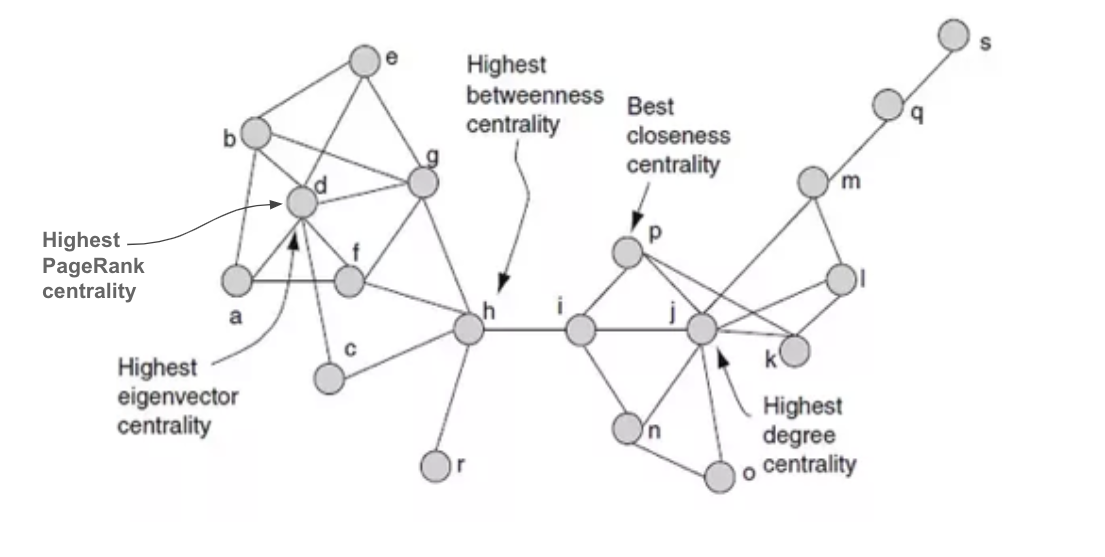

> A useful article for visualising the differences between some other ('centrality'-based) node measures can be found here:
>
> https://aksakalli.github.io/2017/07/17/network-centrality-measures-and-their-visualization.html
>
> **WARNING**: It uses Python 2 and may need adjustment if you want to implement it like-for-like.

<br>
<br>

**Measures concentrated on a node's edges/connections**

**Degree**

```python
nx.degree(G)
```
> The node degree is the number of edges adjacent to the node. - NetworkX Documentation

https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.degree.html



In [16]:
# Create a list of tuples, with each tuple representing (node id, the degree) for each node
# then sort this list of tuples in descending order of degree (i.e., largest to smallest)
degree = sorted(
    [(node[0], node[1]) for node in nx.degree(G)],   
    key=operator.itemgetter(1),                      
    reverse=True
)

# Print out the 10 nodes with the largest degree
for node, d in degree[:10]:
    print(f"Node: {node}   Degree: {d}")
  

Node: 141493   Degree: 77
Node: 98343   Degree: 39
Node: 64605   Degree: 28
Node: 89631   Degree: 24
Node: 125430   Degree: 24
Node: 66893   Degree: 22
Node: 155127   Degree: 22
Node: 116648   Degree: 21
Node: 30520   Degree: 20
Node: 157118   Degree: 20


<br>
<br>

**Degree Centrality**

```python
nx.degree_centrality(G)
```

>The degree centrality for a node v is the fraction of nodes it is connected to... The degree centrality values are normalized by dividing by the maximum possible degree in a simple graph n-1 where n is the number of nodes in G. - NetworkX Documentation

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.degree_centrality.html


In [17]:
# Create a list of tuples, with each tuple representing (node id, the degree centrality) for each node
# then sort this list of tuples in descending order of degree centrality (i.e., largest to smallest)
degree_centrality = sorted(
    [(node[0], node[1]) for node in nx.degree_centrality(G).items()], 
    key=operator.itemgetter(1), 
    reverse=True
)

# Print out the 10 nodes with the largest degree centrality
for node, centrality in degree_centrality[:10]:
    print(f"Node: {node}   Degree Centrality: {centrality:.2f}")

Node: 141493   Degree Centrality: 0.78
Node: 98343   Degree Centrality: 0.39
Node: 64605   Degree Centrality: 0.28
Node: 89631   Degree Centrality: 0.24
Node: 125430   Degree Centrality: 0.24
Node: 66893   Degree Centrality: 0.22
Node: 155127   Degree Centrality: 0.22
Node: 116648   Degree Centrality: 0.21
Node: 30520   Degree Centrality: 0.20
Node: 157118   Degree Centrality: 0.20


> Note that the values of the degree centrality are *similar* to the raw degree values as there are 100 nodes in the dataset.

<br>
<br>

**Measures concentrated on paths in the network involving a node**

**Closeness Centrality**

```python
nx.closeness_centrality(G)
```

> Closeness centrality of a node u is the reciprocal of the average shortest path distance to u over all n-1 reachable nodes... Notice that higher values of closeness indicate higher centrality... The closeness centrality is normalized to (n-1)/(|G|-1) where n is the number of nodes in the connected part of graph containing the node.  - NetworkX Documentation

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.closeness_centrality.html

In [18]:
# Create a list of tuples, with each tuple representing (node id, the closeness centrality) for each node
# then sort this list of tuples in descending order of closeness centrality (i.e., largest to smallest)
closeness_centrality = sorted(
    [(node[0], node[1]) for node in nx.closeness_centrality(G).items()], 
    key=operator.itemgetter(1), 
    reverse=True
)

# Print out the 10 nodes with the largest closeness centrality
for node, centrality in closeness_centrality[:10]:
    print(f"Node: {node}   Closeness Centrality: {centrality:.2f}")

Node: 141493   Closeness Centrality: 0.82
Node: 98343   Closeness Centrality: 0.62
Node: 64605   Closeness Centrality: 0.57
Node: 89631   Closeness Centrality: 0.57
Node: 125430   Closeness Centrality: 0.57
Node: 66893   Closeness Centrality: 0.56
Node: 116648   Closeness Centrality: 0.56
Node: 30520   Closeness Centrality: 0.56
Node: 157118   Closeness Centrality: 0.56
Node: 54230   Closeness Centrality: 0.55


**Betweenness Centrality**

```python
nx.betweenness_centrality(G)
```
> Betweenness centrality of a node is the sum of the fraction of all-pairs shortest paths that pass through that node - NetworkX Documentation

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html

In [19]:
# Create a list of tuples, with each tuple representing (node id, the betweenness centrality) for each node
# then sort this list of tuples in descending order of betweenness centrality (i.e., largest to smallest)
betweenness_centrality = sorted(
    [(node[0], node[1]) for node in nx.betweenness_centrality(G).items()],
    key=operator.itemgetter(1), 
    reverse=True
)

# Print out the 10 nodes with the largest betweenness centrality
for node, centrality in betweenness_centrality[:10]:
    print(f"Node: {node}   Betweenness Centrality: {centrality:.2f}")

Node: 141493   Betweenness Centrality: 0.62
Node: 98343   Betweenness Centrality: 0.12
Node: 64605   Betweenness Centrality: 0.05
Node: 116648   Betweenness Centrality: 0.03
Node: 155127   Betweenness Centrality: 0.03
Node: 30520   Betweenness Centrality: 0.03
Node: 95914   Betweenness Centrality: 0.02
Node: 89631   Betweenness Centrality: 0.02
Node: 125430   Betweenness Centrality: 0.02
Node: 78899   Betweenness Centrality: 0.02


<br>
<br>

In the case of this particular network, the same 3 nodes have the largest centrality scores. This helps to reduce the complexity of nodes to select and investigate in the context of this notebook. However, this may not be the case for every network.

### Comparing models with different initial nodes

Lets explore how the models unfold where the initial node(s) are selected based on different node-based network measures, as well as some random nodes for comparison.

1. Largest betweenness centrality (and degree and closeness)
2. Smallest degree
3. Random
4. Random nodes from the "center" of the network

Here we are going to select 2 nodes (as a new parameter, k) from their network measure scores, rather than a single node seen in earlier sections of this notebook.

In [20]:
# Define the parameters to be used for all of the models.

network = G                    # Set the network to be used, in this case the NetworkX Graph object, G

beta = 0.1                     # Set the global probability of "infection"/information spreading
number_of_iterations = 50      # Set the number of iterations

k = 2                          # Set the number of nodes to be the initial "infected"/sources of the information

s = 200                         # Set the random seed for the model to use

evaluation_threshold = 0.5     # Set the evaluation threshold to be when 50% of the nodes are "infected"/know the information

**Model 1: k-largest betweenness centrality**


2 nodes with the largest betweenness: ('141493', '98343')
Threshold met = True after 4 iterations from the initial iteration


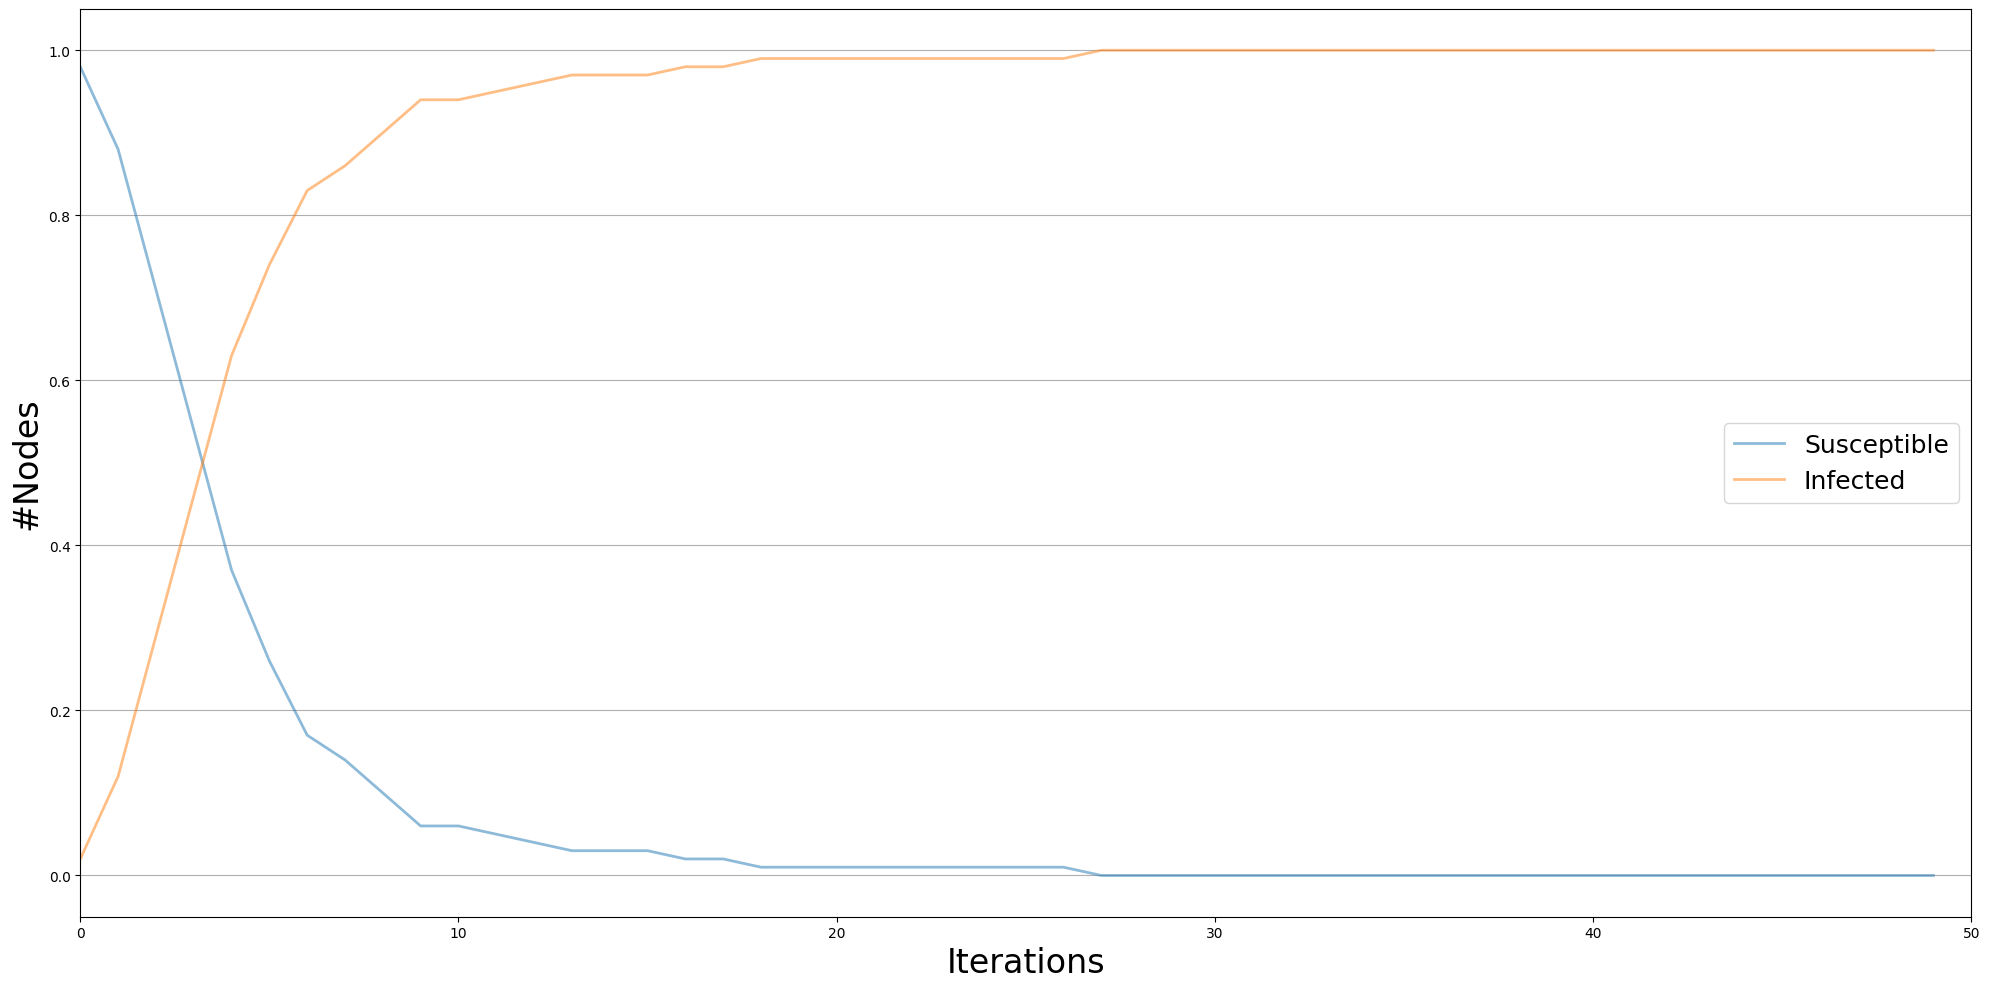

In [21]:
initial_infected_nodes = [node[0] for node in betweenness_centrality[:k]] # Get the node ids for the first k nodes in the betweenness_centrality list from earlier

model, iterations = runSIModelOnANetwork( # Configure and run the model using the method created earlier
    network,
    beta,
    number_of_iterations,
    initial_infected = initial_infected_nodes,
    model_seed = s
)

diffusion_trend, threshold_analysis = evaluateModel(
    network,
    model, 
    iterations, 
    evaluation_threshold,
)

print()
print(f"{k} nodes with the largest betweenness: {*initial_infected_nodes,}")  #Print out the initial nodes used
print(f"Threshold met = {threshold_analysis[0][0]} after {threshold_analysis[0][1]} iterations from the initial iteration")

diffusion_trend.plot()


<br>
<br>

**Model 2: k-smallest degree**

2 nodes with the smallest degree: ('8216', '87479')
Threshold met = True after 12 iterations from the initial iteration


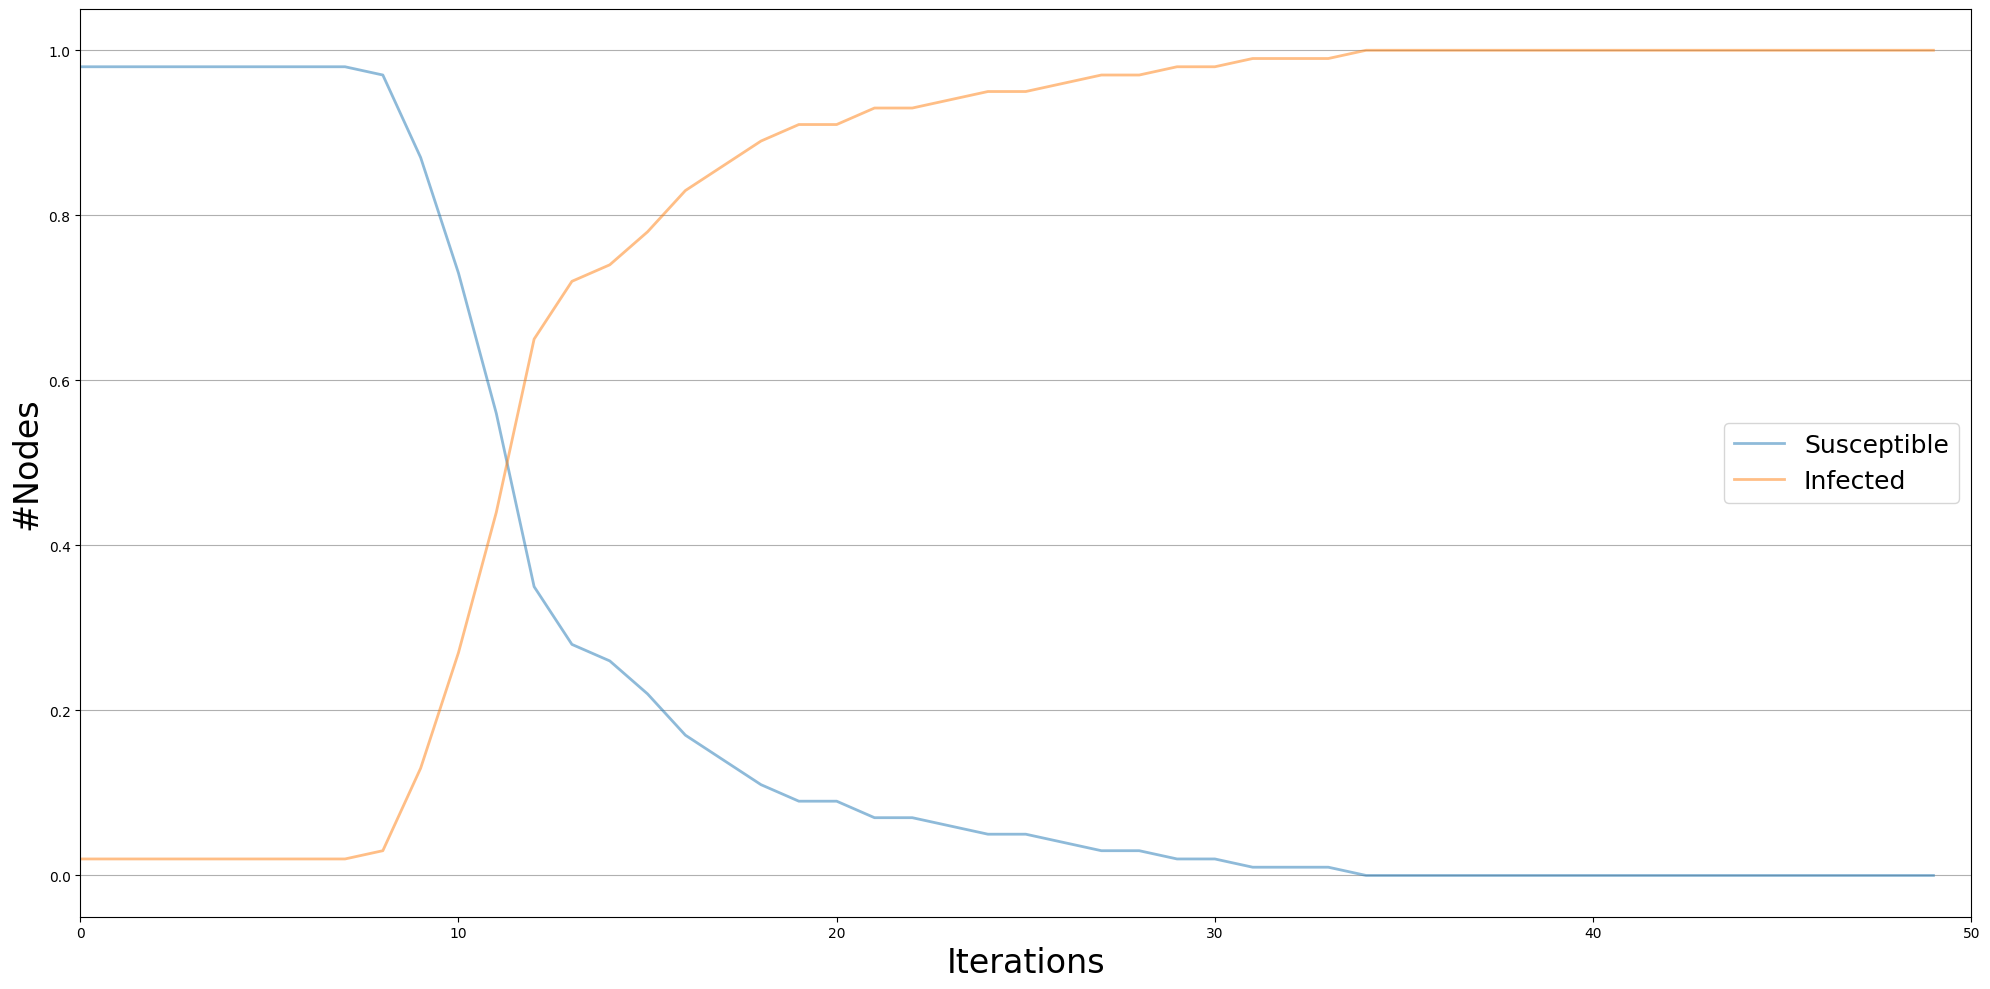

In [22]:
initial_infected_nodes = [node[0] for node in degree[-k:]]

model, iterations = runSIModelOnANetwork(
    network,
    beta,
    number_of_iterations,
    initial_infected = initial_infected_nodes,
    model_seed = s
)

diffusion_trend, threshold_analysis = evaluateModel(
    network,
    model, 
    iterations, 
    evaluation_threshold,
)

print(f"{k} nodes with the smallest degree: {*initial_infected_nodes,}")  #Print out the initial nodes used
print(f"Threshold met = {threshold_analysis[0][0]} after {threshold_analysis[0][1]} iterations from the initial iteration")

diffusion_trend.plot()


<br>
<br>

**Model 3: k-random**

2 random nodes: ('40675', '157585')
Threshold met = True after 8 iterations from the initial iteration


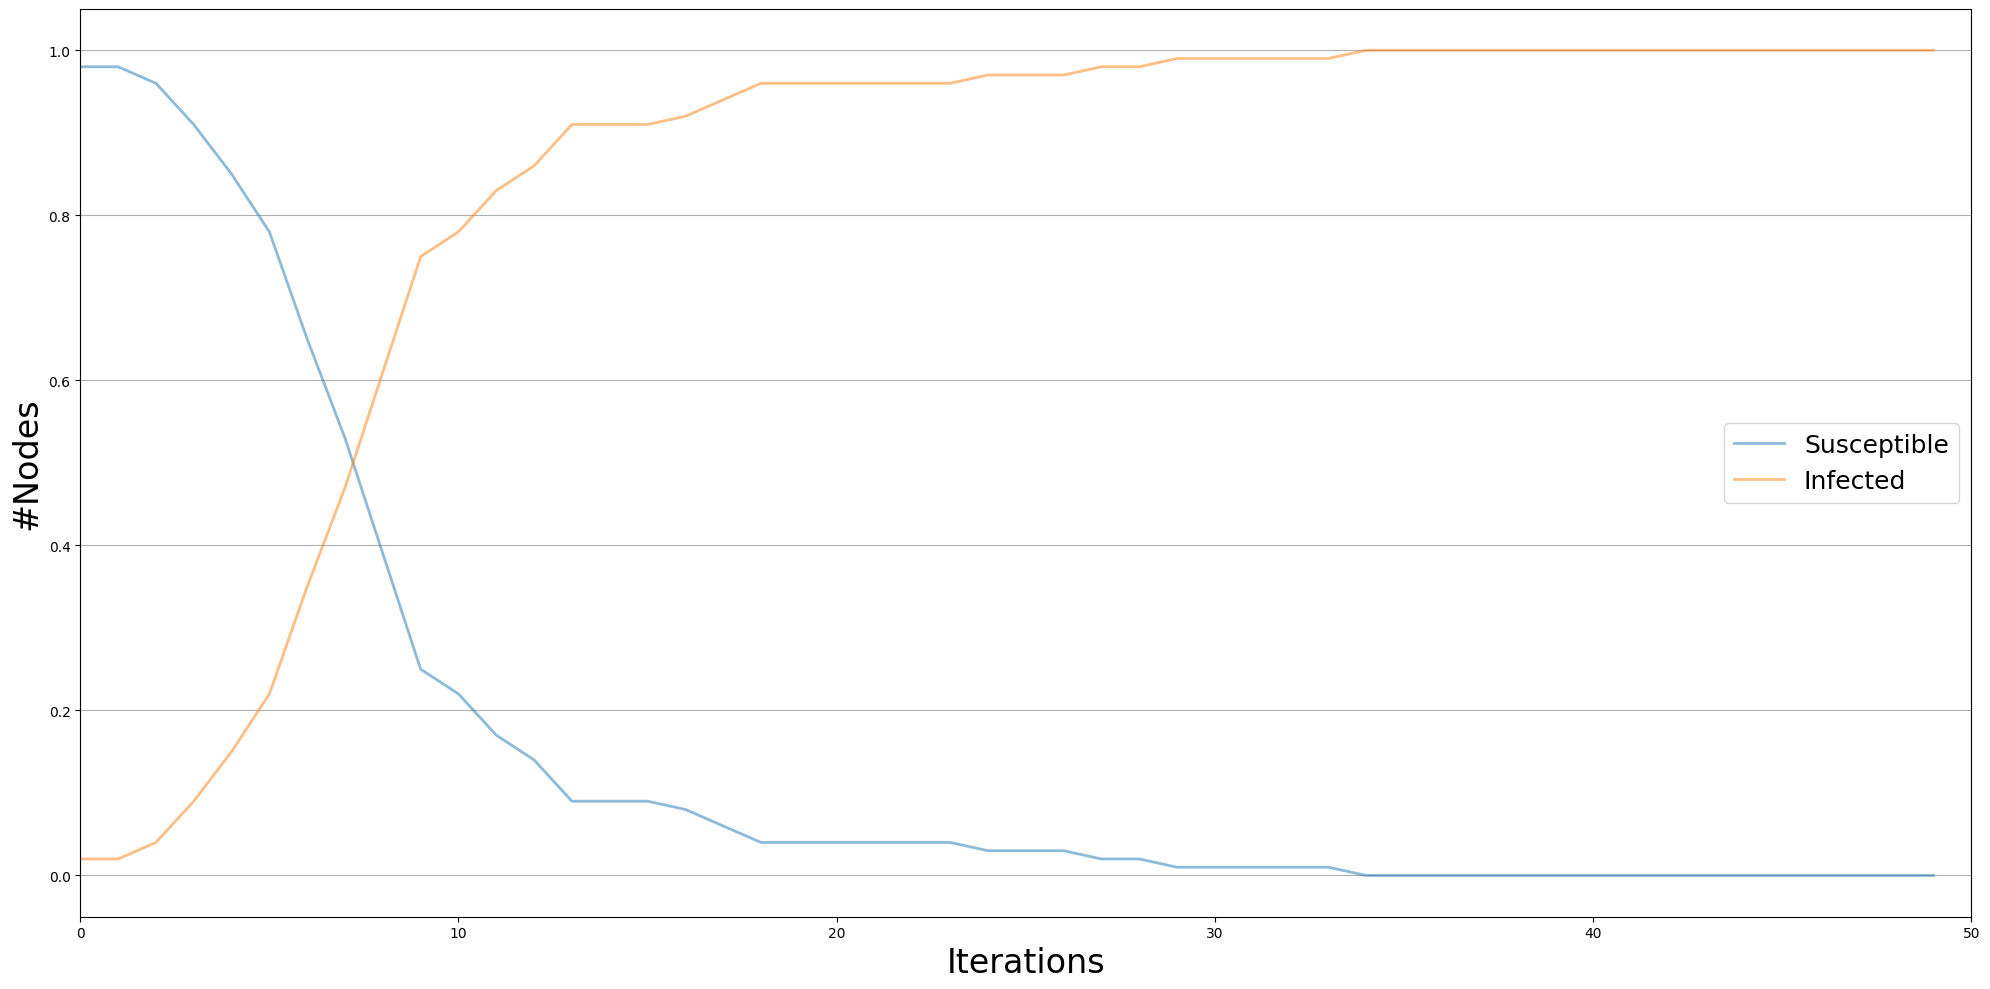

In [23]:
random.seed(1)
initial_infected_nodes = random.sample(list(G.nodes()), k) # Get k random nodes

model, iterations = runSIModelOnANetwork(
    network,
    beta,
    number_of_iterations,
    initial_infected = initial_infected_nodes,
    model_seed = s
)

diffusion_trend, threshold_analysis = evaluateModel(
    network,
    model, 
    iterations, 
    evaluation_threshold,
)

print(f"{k} random nodes: {*initial_infected_nodes,}")  #Print our the initial nodes used
print(f"Threshold met = {threshold_analysis[0][0]} after {threshold_analysis[0][1]} iterations from the initial iteration")

diffusion_trend.plot()


<br>
<br>

**Model 4: k-smallest eccentricity**

2 random nodes from the network center : ('30520', '141493')
Threshold met = True after 4 iterations from the initial iteration


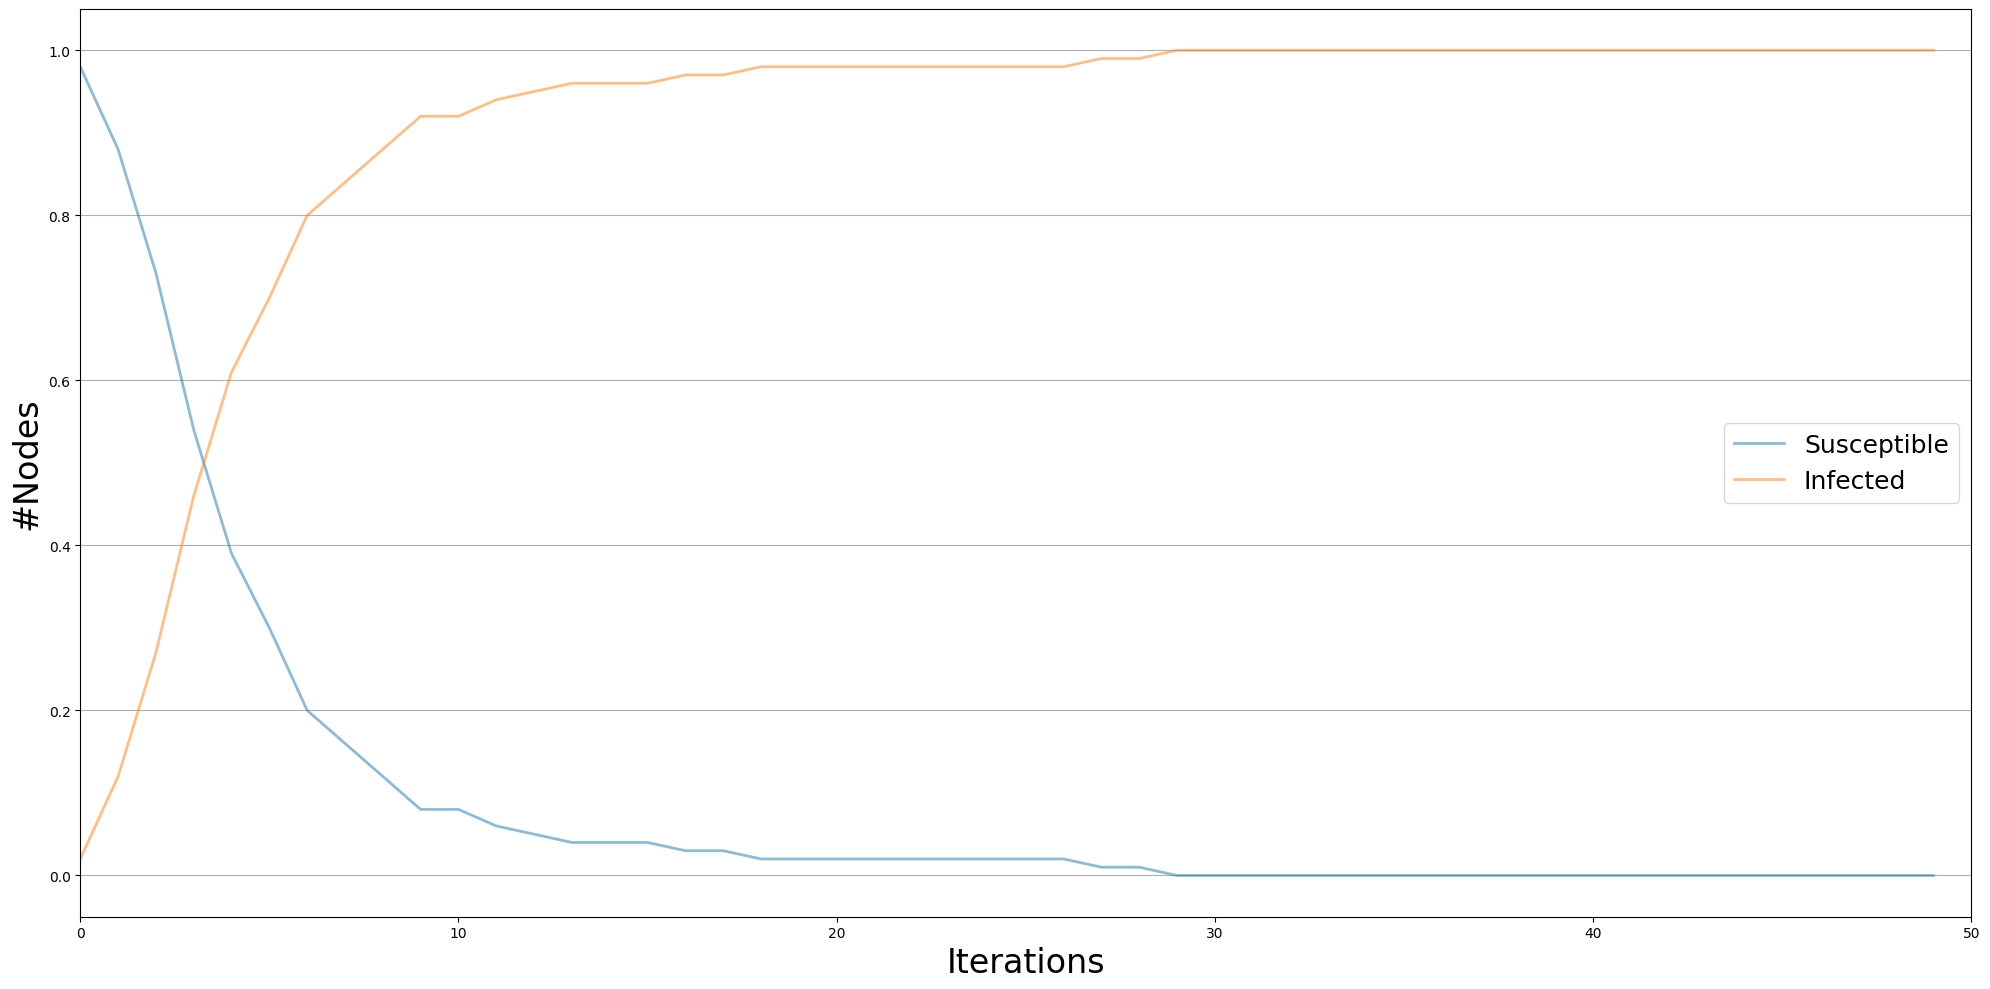

In [24]:
random.seed(1)
initial_infected_nodes = random.sample(list(nx.center(G)), k) # Get k random nodes from the center of the network

model, iterations = runSIModelOnANetwork(
    network,
    beta,
    number_of_iterations,
    initial_infected = initial_infected_nodes,
    model_seed = s
)

diffusion_trend, threshold_analysis = evaluateModel(
    network,
    model, 
    iterations, 
    evaluation_threshold,
)

print(f"{k} random nodes from the network center : {*initial_infected_nodes,}")  #Print our the initial nodes used
print(f"Threshold met = {threshold_analysis[0][0]} after {threshold_analysis[0][1]} iterations from the initial iteration")

diffusion_trend.plot()


<br>
<br>

#### Summary of observations

Some (potentially dangerous) conclusions:

- Selecting random or low connected initially "infected" nodes will result in the "infection"/information spreading slower
- So a targeted approach of selecting nodes that are likely "hubs" or "central" in terms of paths across the network is more likely to be optimal.


>**Extra**: Go back to the cell containing the configuration used for all models and **change the random seed, s, from 200 to 215**. Rerun the cells for 4 models and observe the difference in the results and therefore conclusions.

<br>
<br>

---

<br>
<br>

## 6. Summary and motivations going forward

1. We've taken a first look at using agent-based modelling techniques for analyst tasks surrounding the prediction of socially-driven behaviour, focusing the Susceptible-Infected model framework as a proxy for information spreading.

2. We've built several, basic models that simulate gossiping among a network of people with fixed assumptions and found that analysing the "role" that nodes play in networks can provide an informative basis for how quickly information can spread across the network.

3. However, we could go much further at the risk of complexity. Some examples include:

> - The models here have assumed that information flows freely with a fixed global probability. In reality it may be that nodes are more likely to spread information some of their connections more than others - where a probability per edge rather than globally may be more appropriate.
> 
> - It may also be that a node can spread information to nodes but can't receive information back (i.e., asymmetric ties) - in a similar structure to social networks such as Twitter.
>
> - We've focused on modelling a single piece of information spreading across a network. It may be that information may have a counter opinion and it that individuals have different receptivity to it. 
>
> - The network is also static over time, where in reality new ties/edges may form and some may be removed.

NDlib (as well as similar libraries) can help consider these in the modelling process. A good resource to start to explore these to go through this notebook by Giulio Rossetti, the lead author and developer of NDlib (https://colab.research.google.com/github/KDDComplexNetworkAnalysis/CNA_Tutorials/blob/master/NDlib.ipynb) as well as the NDlib documentation (e.g., https://ndlib.readthedocs.io/en/latest/reference/reference.html#opinion-dynamics)

**Along the way we have:**

- Taken a first look at using Python, NDlib, and NetworkX to build models of social behaviour and consider nodes in networks as agents that as well as being connected together can perform actions that effect the network.

- We've looked at more methods from Graph Theory that, while applied to the tasks specific to the modelling here, are generalisable back to the network analysis tasks in earlier notebooks.



<br>
<br>

---

<br>
<br>

### Extra: Considering multiple "runs" of model simulations

NDlib has APIs to support executing/running models multiple times:

https://ndlib.readthedocs.io/en/latest/reference/utils/multiple_run.html

Lets use this to re-investigate the outcomes of models where the initial "infected" nodes are those with the highest betweenness centrality and the random set of nodes.

In [95]:
# NDlib throws a warning that the model is not configured with an initial set of "infected" nodes. 
# This is because in this block of code we define these in a new "multi_runs(..) method instead.
# For demonstration purposes the two lines of code below turn off the warning from being displayed.
import warnings
warnings.filterwarnings('ignore') 

# Set the configuration used for both models
network = G
number_of_nodes = network.number_of_nodes()

beta = 0.1 # As before
number_of_runs = 50 # The number of times to execute/run each model
number_of_iterations = 50 # As before, the number of iteration of each execution/run of a model

threshold = 0.5

k = 2 # The number of initially "infected" nodes
s = 1 # Random seed


<br>
<br>

**Model Set 1: k-largest betweenness centrality**

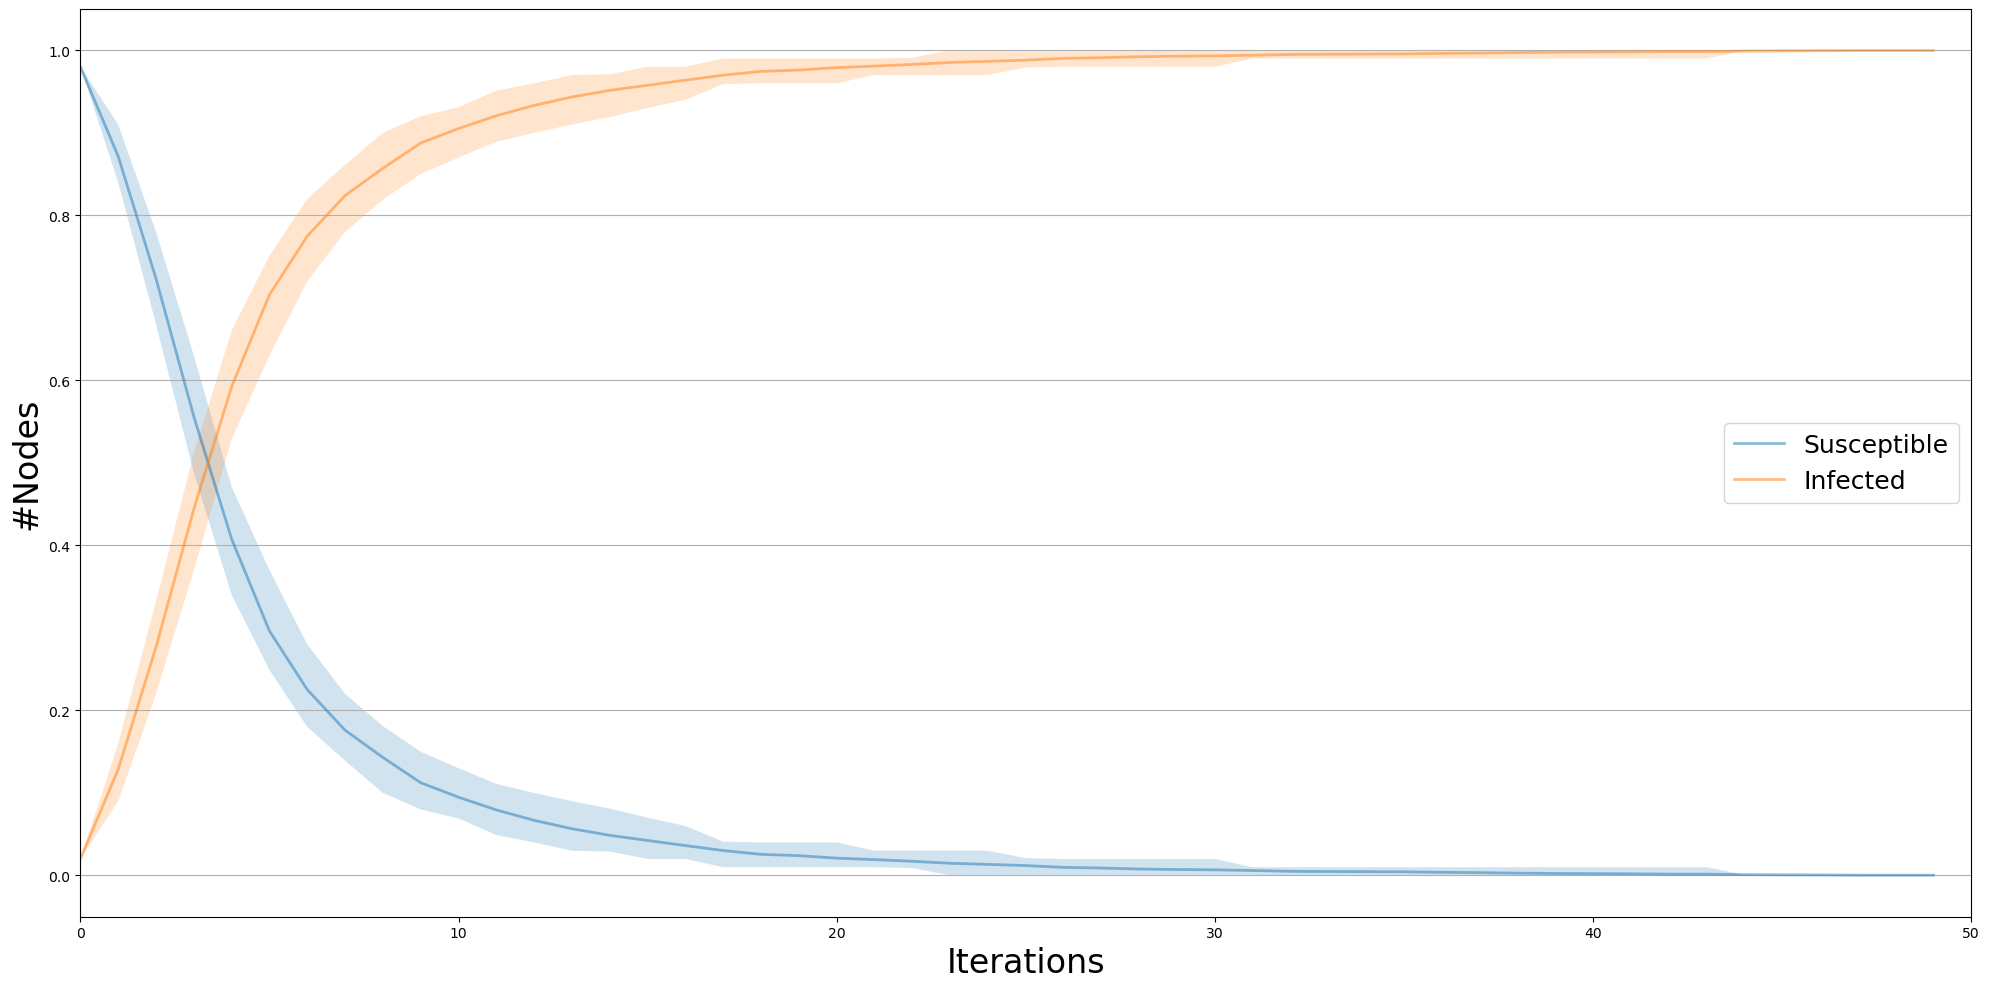

Threshold met in 50/50 runs.
Mean number of iterations to reach threshold = 3.8 (Std Deviation = 0.49)


In [98]:
# Create and configure a SIModel object as before but do not set any initially "infected" nodes (for now)
model = ep.SIModel(network, seed=s)
model_configuration = mc.Configuration()
model_configuration.add_model_parameter('beta', beta)
model.set_initial_status(model_configuration)

# As before choose the k-nodes with the largest betweenness centrality for all nodes
initial_infected_nodes = [node[0] for node in betweenness_centrality[:k]]

trends = multi_runs(
    model,                                                            # The SI model defined above
    execution_number = number_of_runs,                                # The number of times to repeat running the model
    iteration_number = number_of_iterations,                          # The number of iterations per model
    infection_sets = ([initial_infected_nodes] * number_of_runs),     # The initial nodes, a list of identical (sub-)lists in this case
)

viz = DiffusionTrend(model, trends)
viz.plot()

results = calculate_iterations_to_reach_threshold( # Uses the calculate_iterations_to_reach_threshold method defined in Section 3. Custom measures
        trends,
        number_of_nodes,
        threshold,
        False
)

# Loop over the results of the executions/runs that reached the threshold and extract the iteration 
# number where each execution/run reached the threshold as a list
iteration_number_for_executions_that_hit_threshold = [r[1] for r in results if r[0] == True]

print(f"Threshold met in {len(iteration_number_for_executions_that_hit_threshold)}/{number_of_runs} runs.")

# Calculate the average iteration number where the threshold was hit and calculate the standard deviation. Both of these operations use the numpy library
print(f"Mean number of iterations to reach threshold = {np.mean(iteration_number_for_executions_that_hit_threshold)} (Std Deviation = {np.std(iteration_number_for_executions_that_hit_threshold):.2f})")


<br>
<br>

**Model Set 2: k-random**

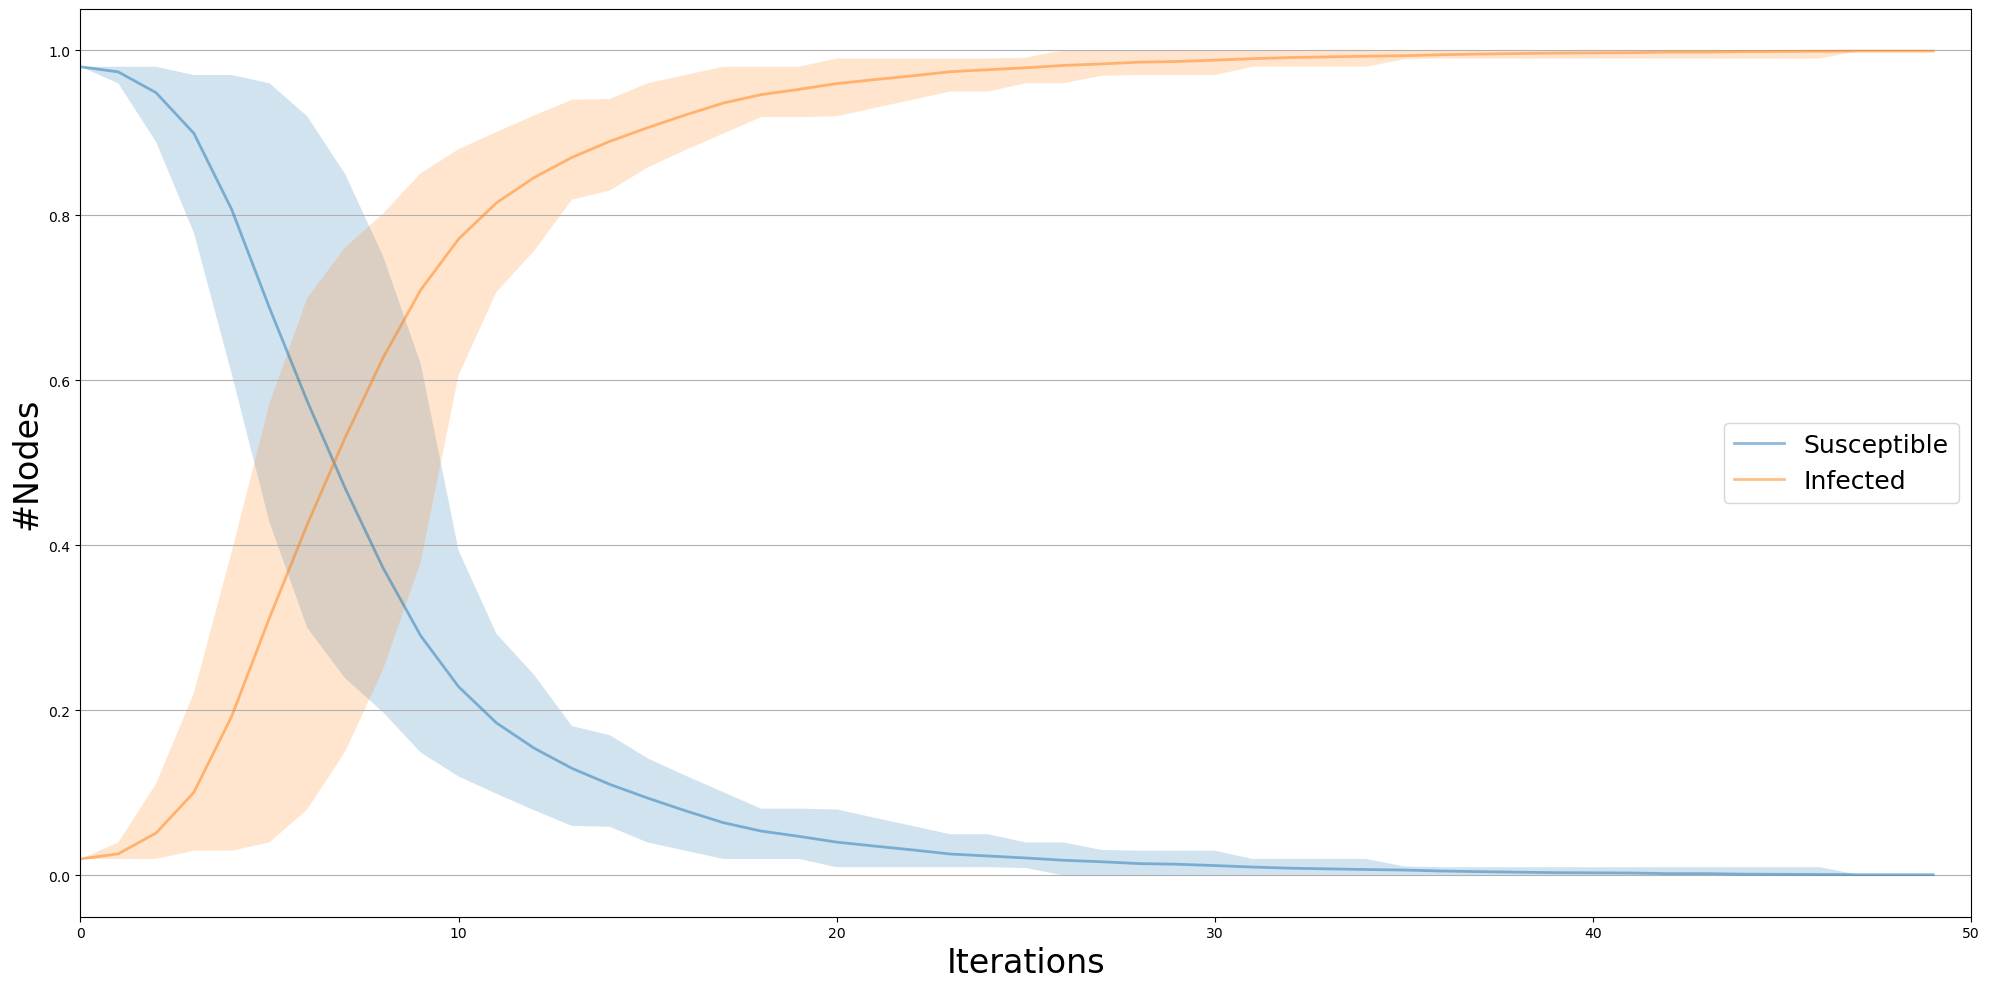

Threshold met in 50/50 runs.
Mean number of iterations to reach threshold = 7.1 (Std Deviation = 2.21)


In [101]:
model = ep.SIModel(network, seed=s)
model_configuration = mc.Configuration()
model_configuration.add_model_parameter('beta', beta)
model.set_initial_status(model_configuration)

# Generate a list of k-random nodes with a fixed random seed
# Here we want to see how different executions/runs of the models with the same starting nodes end up with variance in the results
random.seed(1)
initial_infected_nodes = random.sample(list(G.nodes()), k)

trends = multi_runs(
    model,                                                            # The SI model defined above 
    execution_number = number_of_runs,                                # The number of times to repeat running the model
    iteration_number = number_of_iterations,                          # The number of iterations per model 
    infection_sets = ([initial_infected_nodes] * number_of_runs),     # The initial nodes, a list of identical (sub-)lists in this case 
)

#print(trends) # print the data going into the DiffusionTrend call below
viz = DiffusionTrend(model, trends)
viz.plot()

results = calculate_iterations_to_reach_threshold( # Uses the calculate_iterations_to_reach_threshold method defined in Section 3. Custom measures
        trends,
        number_of_nodes,
        threshold,
        False
)

# Loop over the results of the executions/runs that reached the threshold and extract the iteration 
# number where each execution/run reached the threshold as a list
iteration_number_for_executions_that_hit_threshold = [r[1] for r in results if r[0] == True]

print(f"Threshold met in {len(iteration_number_for_executions_that_hit_threshold)}/{number_of_runs} runs.")

# Calculate the average iteration number where the threshold was hit and calculate the standard deviation. Both of these operations use the numpy library
print(f"Mean number of iterations to reach threshold = {np.mean(iteration_number_for_executions_that_hit_threshold)} (Std Deviation = {np.std(iteration_number_for_executions_that_hit_threshold):.2f})")




<br>
<br>

We could go further with a k-random simulation which could be repeated with different random nodes and multiple executions/runs. (e.g., 50 runs for each of 50 random chosen nodes).

<br>

As the models have randomness embedded into its design (principally here the value of 'beta' not being 1.0), this produces variance in the diffusion trends between each "run" of the model. Its therefore important where there is a random element to a model to not rely on a single execution/run of the model and instead run the execution as many times as possible.
